In [17]:
from astroquery.vizier import Vizier
import astropy.units as u
from astropy.table import Table ,vstack
from astropy.table import join
import matplotlib.pyplot as plt
from astropy.table import unique
import numpy as np
from astropy.io import fits
# viz = Vizier(columns=['*'],row_limit=-1)
#
import scienceplots
import fitsio
import numpy as np
plt.style.use(['science', 'grid','notebook'])
from catboost import CatBoostRegressor  
model = CatBoostRegressor()  
# catalog=viz.get_catalogs("J/MNRAS/525/1106")
# catalog

In [2]:
# #tab4= catalog[4]
# FP=catalog['J/MNRAS/525/1106/tableb4']

# TF=catalog['J/MNRAS/525/1106/tableb5']
# pre1=catalog['J/MNRAS/525/1106/tableb1']
# pre2=catalog['J/MNRAS/525/1106/tableb2']
# pre3=catalog['J/MNRAS/525/1106/tableb3']
# tab6=catalog['J/MNRAS/525/1106/tableb6']
# tab7=catalog['J/MNRAS/525/1106/tableb7']
# tab8=catalog['J/MNRAS/525/1106/tableb8']
# tab9=catalog['J/MNRAS/525/1106/tableb9']

# pre1.write("tab1_desi_pre.fits", format="fits", overwrite=True)
# pre2.write("tab2_desi_pre.fits", format="fits", overwrite=True)
# pre3.write("tab3_desi_pre.fits", format="fits", overwrite=True)
# # tab6.write("tab6_desi.fits", format="fits", overwrite=True)
# tab7.write("tab7_desi.fits", format="fits", overwrite=True)
#tab8.write("tab8_desi.fits", format="fits", overwrite=True)
#tab9.write("tab9_desi.fits", format="fits", overwrite=True)
# FP.write("tab4_desi_fp.fits", format="fits", overwrite=True)
# TF.write("tab5_desi_tf.fits", format="fits", overwrite=True)
# tab8.write("tableb8.parquet", format="parquet", overwrite=True)
# tab9.write("tableb9.parquet", format="parquet", overwrite=True)



In [18]:
def BGS_mask(dr9_chunk):
    cuts2 = (
        (
            ((dr9_chunk['FIBERMAG_R'] < (5.1 + dr9_chunk['MAG_R'])) & (dr9_chunk['MAG_R'] <= 17.8)) |
            ((dr9_chunk['FIBERMAG_R'] < 22.9) & (dr9_chunk['MAG_R'] > 17.8) & (dr9_chunk['MAG_R'] < 20))
        ) &
        ((-1 < (dr9_chunk['MAG_G'] - dr9_chunk['MAG_R'])) &
         ((dr9_chunk['MAG_G'] - dr9_chunk['MAG_R']) < 4) &
         (-1 < (dr9_chunk['MAG_R'] - dr9_chunk['MAG_Z'])) &
         ((dr9_chunk['MAG_R'] - dr9_chunk['MAG_Z']) < 4)) &
        
        (dr9_chunk['NOBS_G'] > 0) &
        (dr9_chunk['NOBS_R'] > 0) &
        (dr9_chunk['NOBS_Z'] > 0) &
        
        (dr9_chunk['FLUX_G'] > 0) &
        (dr9_chunk['FLUX_R'] > 0) &
        (dr9_chunk['FLUX_Z'] > 0) &
        
        (
            ((dr9_chunk['GAIA_PHOT_G_MEAN_MAG'] - dr9_chunk['MAG_NOEXT_R']) > 0.6) |
            (dr9_chunk['GAIA_PHOT_G_MEAN_MAG'] == 0)
        ) &
        
        (~np.isin(dr9_chunk['MASKBITS'], [1, 12, 13])) &
        
        (dr9_chunk['FRACMASKED_G'] < 0.4) &
        (dr9_chunk['FRACMASKED_R'] < 0.4) &
        (dr9_chunk['FRACMASKED_Z'] < 0.4) &
        
        (dr9_chunk['FRACFLUX_G'] < 5) &
        (dr9_chunk['FRACFLUX_R'] < 5) &
        (dr9_chunk['FRACFLUX_Z'] < 5) &
        
        (dr9_chunk['FRACIN_G'] > 0.2) &
        (dr9_chunk['FRACIN_R'] > 0.2) &
        (dr9_chunk['FRACIN_Z'] > 0.2)
    )
    return cuts2



In [ ]:
north= fits.open('/user/animesh.sah/FP_CUTS/table_north_unique_appended.fits')
    hdul.info
    data_south = hdul[1].data
table_2 = Table.read("../tab2_desi_pre.fits", format="fits")
table_2.rename_column('BrickID', 'BRICKID')
table_2.rename_column('ObjID', 'OBJID')
table_2.rename_column('BrickName', 'BRICKNAME')



table_FP = Table.read("../tab4_desi_fp.fits", format="fits")
table_FP.rename_column('BrickID', 'BRICKID')
table_FP.rename_column('ObjID', 'OBJID')
table_FP.rename_column('BrickName', 'BRICKNAME')
table_north = Table(data_north)
south= fits.open('/user/animesh.sah/FP_CUTS/table_south_unique_appended.fits')

data_north = north[1].data  


with fits.open("/user/animesh.sah/FP_CUTS/table_south_unique_appended.fits", memmap=False) as hdul:
    hdul.info
    data_south = hdul[1].data

In [19]:
north= fits.open('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.0234.fits')
south= fits.open('/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits')

data_north = north[1].data  


with fits.open("/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits", memmap=False) as hdul:
    hdul.info
    data_south = hdul[1].data
table_2 = Table.read("../tab2_desi_pre.fits", format="fits")
table_2.rename_column('BrickID', 'BRICKID')
table_2.rename_column('ObjID', 'OBJID')
table_2.rename_column('BrickName', 'BRICKNAME')



table_FP = Table.read("../tab4_desi_fp.fits", format="fits")
table_FP.rename_column('BrickID', 'BRICKID')
table_FP.rename_column('ObjID', 'OBJID')
table_FP.rename_column('BrickName', 'BRICKNAME')
table_north = Table(data_north)
table_south = Table (data_south)

table_north_cut = table_north[table_north['DEC']>-30]
table_south_cut = table_south[table_south['DEC']>-30]

table = vstack([table_north_cut, table_south_cut])
#table

In [22]:
tab0_04= Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.04.fits')[1].read())
tab_0_0234=Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_zpt_0.0234.fits')[1].read())
tab_min0_0234=Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_zpt_-0.0234.fits')[1].read())

tab_0_2=Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.02.fits')[1].read())
tab_min0_04=Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_-0.04.fits')[1].read())
# /user/animesh.sah/FP_CUTS/north_zpt_0.03.fits
# /user/animesh.sah/FP_CUTS/north_zpt_-0.01.fits

In [25]:
tab_0_2

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
326196,0371m007,3000,SER,37.17307614987316,-0.8359418184863707,26.20573,62.307278,111.883766,81.75952,0.9030684,0.93362564,0.9623123,0.99418,3,4,6,0.0022328892,0.0017639098,0.0012555281,0.0031341158,0.0033814926,0.0035261512,0.99995965,0.9999485,0.998597,0.9436603,-0.06782208,-0.05032607,9.370341,22.279114,40.0061,19.861435,0,3.6413803,0.86706173,18.843311,17.919085,17.336372,17.712317,19.959913,19.055687,18.452974,18.95401,18.013653,17.378082,0.07897235,0.057566054
326196,0371m007,3058,SER,37.17605430672796,-0.8465078483625974,83.86569,229.5902,501.12552,417.12515,0.90314215,0.93367696,0.9623419,0.9941847,3,4,4,0.12423383,0.10137634,0.107079454,0.020712847,0.020735841,0.021967635,0.99778974,0.9977973,0.6971285,3.1320574,-0.060779147,0.036701065,12.875178,35.24701,76.93349,0.0,4096,4.113088,2.9170415,17.58043,16.503107,15.708457,15.943002,19.615007,18.557686,17.743034,17.69104,16.597616,15.7501335,0.09622078,0.06397838
326196,0371m007,3091,SER,37.177657616055335,-0.8492741187278495,325.67032,709.0457,1255.1355,917.5338,0.9031664,0.9336938,0.9623516,0.99418616,3,4,4,0.048393108,0.05777874,0.09788793,0.088571526,0.088418484,0.07774617,0.94878775,0.9482651,0.602127,7.264535,0.016855637,-0.041289773,17.04098,37.101425,65.67604,0.0,4096,3.1757193,6.9474654,16.107473,15.278825,14.711608,15.087113,19.310682,18.502035,17.914818,16.218054,15.373314,14.753273,0.06491999,0.03911662
326196,0371m007,3889,SER,37.21882590865914,-0.7677824417206347,116.69464,275.30984,491.5747,386.87775,0.9107296,0.9389536,0.9653802,0.9946609,3,4,7,0.021018406,0.01351206,0.00847735,0.011830271,0.012454596,0.049692936,0.782767,0.70791185,0.97248423,2.1300552,0.12522282,-0.27506393,28.662136,67.62065,120.73889,18.60417,16,4.2346907,1.5592107,17.230846,16.312054,15.732773,16.025253,18.755201,17.856411,17.257128,17.332373,16.400444,15.771027,0.07522254,0.06129543
330518,0376p000,2188,SER,37.63279842543019,-0.0019545315565760286,129.41557,312.4884,555.1835,459.4495,0.93472445,0.9555469,0.9748862,0.9961429,2,4,5,2.8071702,0.26776132,0.32795915,0.235933,0.70116514,0.11472735,0.66577125,0.798964,0.9986286,2.9530487,-0.36729765,0.04423549,30.625507,73.94872,131.38123,18.395773,2072,6.0,2.0026488,17.146742,16.193544,15.611294,15.84021,18.7115,17.778303,17.176052,17.220034,16.262915,15.638908,0.09018374,0.04117998
330518,0376p000,2694,SER,37.66204658050864,-0.02072201115528884,55.177284,111.304146,191.9303,265.00772,0.9329061,0.9542944,0.97417116,0.9960319,3,5,4,0.0073353946,0.002340394,0.00096253474,0.009537279,0.008925471,0.009590004,0.99465364,0.9954977,0.9958475,1.369642,0.15997021,0.112553276,18.384657,37.085705,63.949734,18.938347,0,5.672823,1.1234426,18.070194,17.312927,16.76373,16.437536,19.263456,18.52619,17.956991,18.1456,17.38372,16.792141,0.14954486,0.09452175
326197,0373m007,433,SER,37.274392030708654,-0.8544710044826774,140.88066,294.3703,487.85464,295.36725,0.9090317,0.937774,0.96470165,0.9945547,3,5,4,0.0029706631,0.0027493846,0.0007871838,0.05132572,0.083003536,0.048110005,0.9640522,0.9644914,0.6451703,3.6648996,-0.09353421,-0.047296334,24.858915,51.942734,86.08376,18.727901,0,6.0,3.298944,17.024319,16.23801,15.740256,16

In [24]:
tab0_04

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
326196,0371m007,3000,SER,37.17307614987316,-0.8359418184863707,26.20573,62.307278,111.883766,81.75952,0.9030684,0.93362564,0.9623123,0.99418,3,4,6,0.0022328892,0.0017639098,0.0012555281,0.0031341158,0.0033814926,0.0035261512,0.99995965,0.9999485,0.998597,0.9436603,-0.06782208,-0.05032607,9.370341,22.279114,40.0061,19.861435,0,3.6413803,0.86706173,18.843311,17.899084,17.336372,17.712317,19.959913,19.055687,18.452974,18.95401,18.013653,17.378082,0.07897235,0.057566054
326196,0371m007,3058,SER,37.17605430672796,-0.8465078483625974,83.86569,229.5902,501.12552,417.12515,0.90314215,0.93367696,0.9623419,0.9941847,3,4,4,0.12423383,0.10137634,0.107079454,0.020712847,0.020735841,0.021967635,0.99778974,0.9977973,0.6971285,3.1320574,-0.060779147,0.036701065,12.875178,35.24701,76.93349,0.0,4096,4.113088,2.9170415,17.58043,16.483107,15.708457,15.943002,19.615007,18.557686,17.743034,17.69104,16.597616,15.7501335,0.09622078,0.06397838
326196,0371m007,3091,SER,37.177657616055335,-0.8492741187278495,325.67032,709.0457,1255.1355,917.5338,0.9031664,0.9336938,0.9623516,0.99418616,3,4,4,0.048393108,0.05777874,0.09788793,0.088571526,0.088418484,0.07774617,0.94878775,0.9482651,0.602127,7.264535,0.016855637,-0.041289773,17.04098,37.101425,65.67604,0.0,4096,3.1757193,6.9474654,16.107473,15.258825,14.711608,15.087113,19.310682,18.502035,17.914818,16.218054,15.373314,14.753273,0.06491999,0.03911662
326196,0371m007,3889,SER,37.21882590865914,-0.7677824417206347,116.69464,275.30984,491.5747,386.87775,0.9107296,0.9389536,0.9653802,0.9946609,3,4,7,0.021018406,0.01351206,0.00847735,0.011830271,0.012454596,0.049692936,0.782767,0.70791185,0.97248423,2.1300552,0.12522282,-0.27506393,28.662136,67.62065,120.73889,18.60417,16,4.2346907,1.5592107,17.230846,16.292053,15.732773,16.025253,18.755201,17.856411,17.257128,17.332373,16.400444,15.771027,0.07522254,0.06129543
330518,0376p000,2188,SER,37.63279842543019,-0.0019545315565760286,129.41557,312.4884,555.1835,459.4495,0.93472445,0.9555469,0.9748862,0.9961429,2,4,5,2.8071702,0.26776132,0.32795915,0.235933,0.70116514,0.11472735,0.66577125,0.798964,0.9986286,2.9530487,-0.36729765,0.04423549,30.625507,73.94872,131.38123,18.395773,2072,6.0,2.0026488,17.146742,16.173544,15.611294,15.84021,18.7115,17.778303,17.176052,17.220034,16.262915,15.638908,0.09018374,0.04117998
330518,0376p000,2694,SER,37.66204658050864,-0.02072201115528884,55.177284,111.304146,191.9303,265.00772,0.9329061,0.9542944,0.97417116,0.9960319,3,5,4,0.0073353946,0.002340394,0.00096253474,0.009537279,0.008925471,0.009590004,0.99465364,0.9954977,0.9958475,1.369642,0.15997021,0.112553276,18.384657,37.085705,63.949734,18.938347,0,5.672823,1.1234426,18.070194,17.292927,16.76373,16.437536,19.263456,18.52619,17.956991,18.1456,17.38372,16.792141,0.14954486,0.09452175
326197,0373m007,1542,DEV,37.34321949535508,-0.646802966244248,32.710278,83.6405,159.03944,133.942,0.91050535,0.93879783,0.96529067,0.9946469,3,5,5,0.04235444,0.03904382,0.036861405,6.0492923e-05,7.844963e-05,0.00021889103,1.0000001,1.0000001,1.0000001,0.5646698,0.1496274,-0.024434742,15.778294,40.34525,76.71506,19.187542,0,4.0,0.484663,18.611496,17.585388,16.957882,17.1

In [23]:
tab_min0_04

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
326196,0371m007,3000,SER,37.17307614987316,-0.8359418184863707,26.20573,62.307278,111.883766,81.75952,0.9030684,0.93362564,0.9623123,0.99418,3,4,6,0.0022328892,0.0017639098,0.0012555281,0.0031341158,0.0033814926,0.0035261512,0.99995965,0.9999485,0.998597,0.9436603,-0.06782208,-0.05032607,9.370341,22.279114,40.0061,19.861435,0,3.6413803,0.86706173,18.843311,17.979086,17.336372,17.712317,19.959913,19.055687,18.452974,18.95401,18.013653,17.378082,0.07897235,0.057566054
326196,0371m007,3091,SER,37.177657616055335,-0.8492741187278495,325.67032,709.0457,1255.1355,917.5338,0.9031664,0.9336938,0.9623516,0.99418616,3,4,4,0.048393108,0.05777874,0.09788793,0.088571526,0.088418484,0.07774617,0.94878775,0.9482651,0.602127,7.264535,0.016855637,-0.041289773,17.04098,37.101425,65.67604,0.0,4096,3.1757193,6.9474654,16.107473,15.338825,14.711608,15.087113,19.310682,18.502035,17.914818,16.218054,15.373314,14.753273,0.06491999,0.03911662
326196,0371m007,3889,SER,37.21882590865914,-0.7677824417206347,116.69464,275.30984,491.5747,386.87775,0.9107296,0.9389536,0.9653802,0.9946609,3,4,7,0.021018406,0.01351206,0.00847735,0.011830271,0.012454596,0.049692936,0.782767,0.70791185,0.97248423,2.1300552,0.12522282,-0.27506393,28.662136,67.62065,120.73889,18.60417,16,4.2346907,1.5592107,17.230846,16.372055,15.732773,16.025253,18.755201,17.856411,17.257128,17.332373,16.400444,15.771027,0.07522254,0.06129543
330518,0376p000,2188,SER,37.63279842543019,-0.0019545315565760286,129.41557,312.4884,555.1835,459.4495,0.93472445,0.9555469,0.9748862,0.9961429,2,4,5,2.8071702,0.26776132,0.32795915,0.235933,0.70116514,0.11472735,0.66577125,0.798964,0.9986286,2.9530487,-0.36729765,0.04423549,30.625507,73.94872,131.38123,18.395773,2072,6.0,2.0026488,17.146742,16.253546,15.611294,15.84021,18.7115,17.778303,17.176052,17.220034,16.262915,15.638908,0.09018374,0.04117998
326197,0373m007,433,SER,37.274392030708654,-0.8544710044826774,140.88066,294.3703,487.85464,295.36725,0.9090317,0.937774,0.96470165,0.9945547,3,5,4,0.0029706631,0.0027493846,0.0007871838,0.05132572,0.083003536,0.048110005,0.9640522,0.9644914,0.6451703,3.6648996,-0.09353421,-0.047296334,24.858915,51.942734,86.08376,18.727901,0,6.0,3.298944,17.024319,16.298012,15.740256,16.318165,18.907742,18.141434,17.62368,17.12787,16.327765,15.779274,0.03089841,0.02015233
326197,0373m007,1542,DEV,37.34321949535508,-0.646802966244248,32.710278,83.6405,159.03944,133.942,0.91050535,0.93879783,0.96529067,0.9946469,3,5,5,0.04235444,0.03904382,0.036861405,6.0492923e-05,7.844963e-05,0.00021889103,1.0000001,1.0000001,1.0000001,0.5646698,0.1496274,-0.024434742,15.778294,40.34525,76.71506,19.187542,0,4.0,0.484663,18.611496,17.66539,16.957882,17.17688,19.403055,18.416948,17.749443,18.71329,17.693958,16.996239,0.097553335,0.0714637
323316,0371m012,358,SER,37.013059078858426,-1.1303452690837223,253.02322,548.0874,952.521,592.4401,0.9016832,0.93266064,0.9617558,0.99409264,2,2,5,0.046944074,0.08348886,0.009057983,0.17590944,0.17652667,0.19952247,0.5946174,0.45286337,0.8855704,13.4144,0.080422625,-0.19330147,16.000805,34.660217,60.235977,0.0,0,5.508858,10.846287,16.379734,15.617185,15.010475,15.561955,19.377281,

In [16]:
tab_0_0234

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
321871,0358m015,3250,DEV,35.98005109555428,-1.4362862687724658,28.631094,74.261375,144.37477,116.812164,0.9160526,0.9426468,0.96750236,0.99499285,3,4,2,0.004572276,0.0026260752,0.0012449323,0.06669776,0.06695476,0.068505526,0.852012,0.8393499,0.9874783,2.8428051,0.14029127,0.1801913,5.276654,13.686224,26.60798,0.0,0,4.0,2.2531462,18.762707,17.758965,17.065401,17.325829,20.598904,19.595163,18.9016,18.857904,17.823093,17.10127,0.11874644,0.09539488
321873,0363m015,3608,SER,36.48425547500112,-1.508209170380181,34.59732,75.73529,129.80052,110.12468,0.9078928,0.93698245,0.9642461,0.9944833,4,6,2,0.012906574,0.007608779,0.007855544,0.13513671,0.13587865,0.19468026,0.9478859,0.94898057,0.95328254,4.368883,0.103089295,0.0073134955,4.8492064,10.615158,18.193012,0.0,0,5.1800385,3.9384556,18.54748,17.731083,17.177279,17.389282,20.68091,19.864513,19.310707,18.652393,17.801754,17.216808,0.14497311,0.097543634
321879,0378m015,4122,SER,37.995359035967155,-1.5301685395762539,29.487047,69.058784,118.8772,82.644905,0.90135795,0.932434,0.9616251,0.99407214,3,6,2,0.0027452118,0.0035739944,0.0037212025,0.018565085,0.017860534,0.01806179,0.99242675,0.9931141,0.99523735,1.953702,-0.10092728,-0.0685173,6.3163824,14.792994,25.46453,0.0,0,3.244437,1.7282822,18.713165,17.825998,17.269768,17.700504,20.386072,19.498905,18.942675,18.825922,17.901953,17.312252,0.07257466,0.053681612
321880,0381m015,680,SER,38.04467748411576,-1.4045911751128217,29.824102,76.862236,142.08818,112.795784,0.89328617,0.9268011,0.9583713,0.9935603,2,4,2,0.0041986136,0.003936184,0.0035697322,0.007325321,0.0065476904,0.006617283,0.9985576,0.99876785,0.99901253,1.4889864,-0.16061729,0.06864678,8.840027,22.782385,42.11571,19.835178,0,4.5497236,1.2480894,18.691057,17.703184,17.07244,17.362253,20.011343,19.023468,18.392723,18.813581,17.785717,17.118605,0.115761474,0.09674331
321880,0381m015,1318,SER,38.09007864354023,-1.4842546091831508,35.579334,83.827675,143.35915,99.44671,0.891174,0.9253243,0.95751685,0.99342567,3,6,3,0.0012131402,0.00089586905,0.02325543,0.016120914,0.013634458,0.011534644,0.756388,0.9966776,0.72361493,2.767874,0.0343871,0.21169545,5.372689,12.658472,21.648075,0.0,0,2.5003939,2.2260466,18.496912,17.607265,17.061802,17.498863,20.549427,19.659782,19.114317,18.622005,17.691532,17.108936,0.07436775,0.05436599
321880,0381m015,1681,SER,38.113504025273436,-1.5307999464636837,172.7598,361.75128,656.5921,593.4223,0.8956982,0.92848605,0.9593455,0.9937137,3,6,2,0.0024279535,0.0017309351,0.0012761037,0.010906371,0.010854813,0.010054797,0.99965763,0.99967414,0.99972355,3.8841667,0.22826964,-0.27533242,21.502268,45.024788,81.72167,0.0,4096,2.6225405,2.671707,16.786797,16.023413,15.411698,15.559744,19.049194,18.285809,17.674095,16.906393,16.103973,15.45676,0.07714935,0.048210632
321882,0386m015,1124,SER,38.57015384926577,-1.4197640387238006,137.2096,299.81647,510.8631,363.24307,0.9175506,0.94368494,0.96809816,0.99508595,4,7,2,0.0071179396,0.0057143546,0.0012104354,0.070477046,0.071101524,0.076630294,0.9245541,0.9248766,0.9244917,5.1788263,0.12927844,-0.07008517,19.41209,42.41733,72.27572,19.036583,0,6.0,4.46581,17.063114,16.244928,15.6940365,16.094

In [23]:
table.columns

<TableColumns names=('BRICKID','BRICKNAME','OBJID','TYPE','RA','DEC','FLUX_G','FLUX_R','FLUX_Z','MW_TRANSMISSION_G','MW_TRANSMISSION_R','MW_TRANSMISSION_Z','NOBS_G','NOBS_R','NOBS_Z','FRACFLUX_G','FRACFLUX_R','FRACFLUX_Z','FRACMASKED_G','FRACMASKED_R','FRACMASKED_Z','FRACIN_G','FRACIN_R','FRACIN_Z','SHAPE_R','SHAPE_E1','SHAPE_E2','FIBERFLUX_G','FIBERFLUX_R','FIBERFLUX_Z','GAIA_PHOT_G_MEAN_MAG','MASKBITS','SERSIC','R_CIRC','MAG_G','MAG_R','MAG_Z','FIBERMAG_G','FIBERMAG_R','FIBERMAG_Z','MAG_NOEXT_G','MAG_NOEXT_R','MAG_NOEXT_Z','Z_PHOT_MEDIAN','Z_PHOT_L95','PSFDEPTH_G','PSFDEPTH_R','PSFDEPTH_Z','GALDEPTH_G','GALDEPTH_R','GALDEPTH_Z')>

In [6]:
len(table_north_cut), len(table_south_cut)


(144694, 337336)

In [19]:
len(table_north_cut), len(table_south_cut)



(143560, 337336)

In [9]:
4705-3560 , 339405-337336


(1145, 2069)

In [27]:
common = join(
    table_2,
    table,
    keys=[  'BRICKID','OBJID','BRICKNAME'],
    join_type='inner'
)

In [22]:
143560+337336

480896

In [ ]:
#common[['OBJID'	,'BRICKID','gmag','MAG_G','rmag','MAG_R','zmag','MAG_Z','RadCirc','R_CIRC']]
north_mask=BGS_mask(table_north_cut)
south_mask=BGS_mask(table_south_cut)
table_north = table_north_cut[north_mask]
table_south = table_south_cut[south_mask]
print(len(table_north), len(table_south))

table_north_unique = unique(table_north, keys=['BRICKID', 'OBJID'])
table_south_unique = unique(table_south, keys=['BRICKID', 'OBJID'])
print(len(table_north_unique), len(table_south_unique))
#table_north_unique.write("../../FP_CUTS/table_north_unique_zpt_shifted_00234.fits", format="fits", overwrite=True)
# table_south_unique.write("../../FP_CUTS/table_south_unique_appended.fits", format="fits", overwrite=True)

143560 337336
143560 337336


In [10]:
table_zpt_shifted = vstack([table_north_unique, table_south_unique])
table_zpt_shifted.write("../../FP_CUTS/table_zpt_shifted_00234.fits", format="fits", overwrite=True)

In [28]:
#from astropy.io import fits
#from astropy.table import unique

unique_table = unique(table, keys=['BRICKID', 'OBJID'])
#table_match_final = table[full_mask]
# Save the table as a FITS file
unique_table.write('unique_table_w1.fits', format='fits', overwrite=True)
#print('Saved table_match_final.fits')

<TableColumns names=('BRICKID','BRICKNAME','OBJID','TYPE','RA','DEC','FLUX_G','FLUX_R','FLUX_Z','MW_TRANSMISSION_G','MW_TRANSMISSION_R','MW_TRANSMISSION_Z','NOBS_G','NOBS_R','NOBS_Z','FRACFLUX_G','FRACFLUX_R','FRACFLUX_Z','FRACMASKED_G','FRACMASKED_R','FRACMASKED_Z','FRACIN_G','FRACIN_R','FRACIN_Z','SHAPE_R','SHAPE_E1','SHAPE_E2','FIBERFLUX_G','FIBERFLUX_R','FIBERFLUX_Z','GAIA_PHOT_G_MEAN_MAG','MASKBITS','SERSIC','R_CIRC','MAG_G','MAG_R','MAG_Z','FIBERMAG_G','FIBERMAG_R','FIBERMAG_Z','MAG_NOEXT_G','MAG_NOEXT_R','MAG_NOEXT_Z','Z_PHOT_MEDIAN','Z_PHOT_L95')>

In [29]:
keys_tab2 = set(zip(table_2['BRICKID'], table_2['OBJID'], table_2['BRICKNAME']))
keys_table = set(zip(table['BRICKID'], table['OBJID'],table['BRICKNAME']))


In [30]:
unmatched_keys = keys_table - keys_tab2


In [31]:
mask = [(brickid, objid,brickname) in unmatched_keys for brickid, objid,brickname in zip(table['BRICKID'], table['OBJID'],table['BRICKNAME'])]
unmatched_rows = table[mask]

In [32]:
ra_array=table_FP['RA_ICRS']
dec_array=table_FP['DE_ICRS']

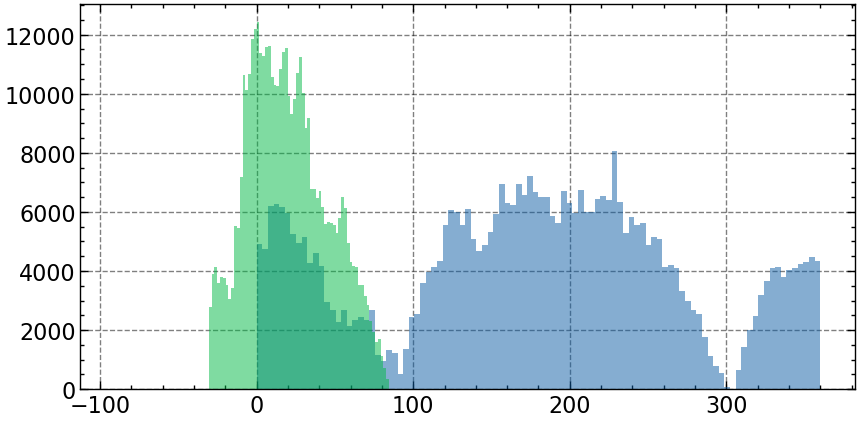

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(ra_array, bins=100, range=(0, 360), alpha=0.5, label='RA')
plt.hist(dec_array, bins=100, range=(-90, 90), alpha=0.5, label='Dec')
plt.show()

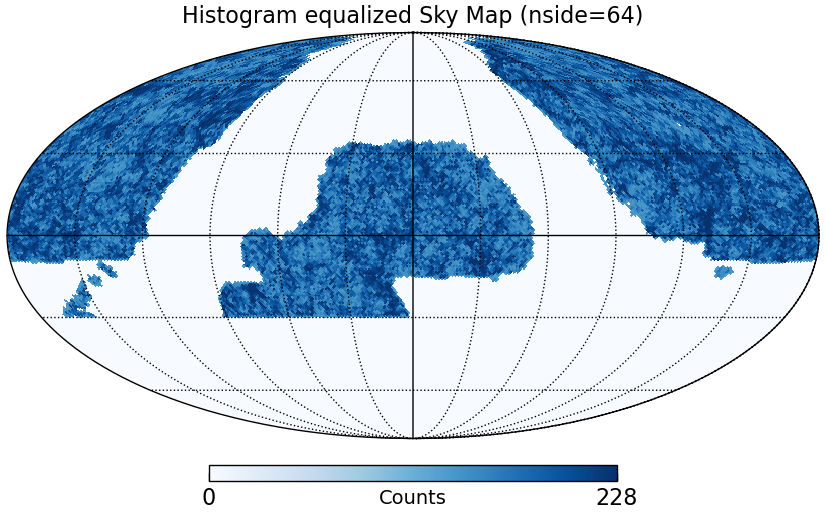

In [33]:
import healpy as hp
import numpy as np
import healpy.visufunc as hv

nside =64
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - dec_array.data)  # theta = 0 at North Pole
phi = np.radians(ra_array.data) 
pix_indices = hp.ang2pix(nside, theta, phi)
hpx_map = np.zeros(npix, dtype=int)

ix,counts=np.unique(pix_indices,return_counts=True)
   # fill the fullsky map
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map,cmap='Blues', unit='Counts',norm='hist',title=f"Histogram equalized Sky Map (nside={nside})")
hp.graticule()

In [34]:
sky_map = np.zeros(npix)

# Count number of sources per pixel
for pix in pix_indices:
    sky_map[pix] += 1
sky_map = np.bincount(pix_indices, minlength=npix)



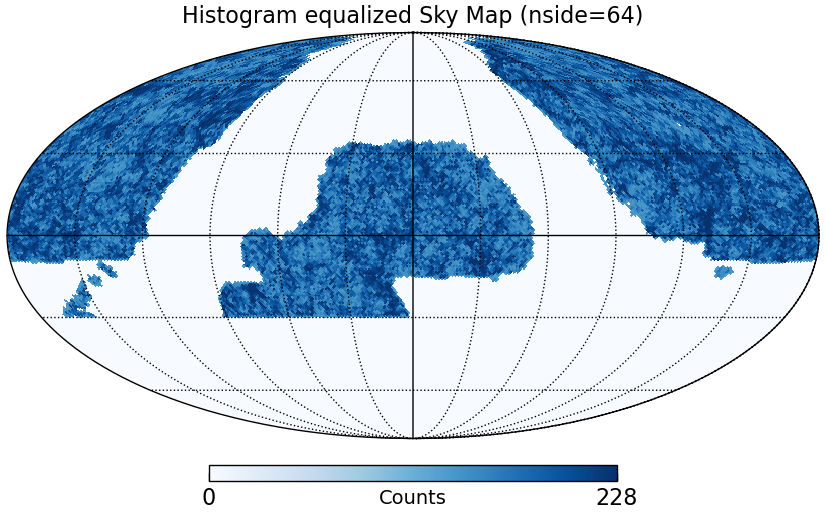

In [35]:
hp.mollview(sky_map, title=f"Histogram equalized Sky Map (nside={nside})",cmap='Blues', unit='Counts',norm='hist')
hp.graticule()
plt.show()

In [9]:
table_vizier_south = Table.read("../../FP_CUTS/south_cuts_vizier.fits", format="fits")
table_vizier_north = Table.read("../../FP_CUTS/north_cuts_vizier.fits", format="fits")


In [55]:
len(table_vizier_north) +len(table_vizier_south) -12449

427273

In [21]:
north_coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(2.42916978e-01, -1.50878769), (1.07554979e+00, -1.43967214),
     (2.53912665e+00, -1.48498054), ..., (3.50488948e+02, 29.89548033),
     (3.51046818e+02, 29.92807316), (3.52293863e+02, 29.97540535)]>

In [ ]:
len(north_coords) +len(south_coords) 

439722

In [62]:
idx_north

array([ 94616, 113384, 113955, 115102, 281870, 282182, 283840, 286353,
       288791, 288922, 290133, 290260, 290324, 290728, 290733, 293431,
       295517, 295517, 296541, 296938, 297142, 297573, 298142, 298165,
       298748, 299304, 299367, 299369, 299549, 299997, 300019, 300271,
       300521, 300614, 301256, 301349, 302057, 302462, 302603, 302604,
       302843, 302865, 303191, 304034, 304040, 304590, 304950, 305279,
       305291, 305372, 305588, 305783, 305987, 306268, 306420])

In [66]:
idx_south, idx_north, sep2d, sep3d = north_coords.search_around_sky(south_coords, max_sep)
north_matches = table_vizier_north[idx_north]
south_matches = table_vizier_south[idx_south]

#matched = hstack([north_matches, south_matches])
#matched['sep_arcsec'] = sep2d.arcsec

In [67]:
len(north_matches)

55

In [ ]:
505949	1057p320	3617

In [86]:
table_vizier_north[ (table_vizier_north['BRICKNAME'] =='1057p320' ) ]

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32
505949,1057p320,2771,PSF,105.75664252968453,32.10500639598364,0.2238576,0.6497253,1.2105923,0.78887063,0.852357,0.91451937,3,6,3,1.6701318,0.51526004,1.0146228,0.02346854,0.008405449,0.024363603,0.99911475,0.99956495,0.99620134,0.0,0.0,0.0,0.17421173,0.5056329,0.9421139,0.0,0,0.0,0.0,23.867584,22.79473,22.195488,24.13982,23.066965,22.467724,24.12507,22.968176,22.292505,105.80873370823,31.99810827279,2015.5,false,FPT,1,1,2843260150087680,0.48925844,0.15438838


In [52]:
from astropy.coordinates import SkyCoord
import astropy.units as u
table_vizier_north = unique(table_vizier_north, keys=['BRICKID', 'OBJID','BRICKNAME'])
table_vizier_south = unique(table_vizier_south, keys=['BRICKID', 'OBJID','BRICKNAME'])


north_coords = SkyCoord(table_vizier_north['RA']*u.deg,table_vizier_north['DEC']*u.deg)
south_coords = SkyCoord(table_vizier_south['RA']*u.deg,table_vizier_south['DEC']*u.deg)

idx, d2d, d3d = north_coords.match_to_catalog_sky(south_coords)
max_sep = 10 * u.arcsec
sep_constraint = d2d < max_sep
north_matched = table_vizier_north[sep_constraint]
#north_matched = table_vizier_north[table_vizier_north['DEC'] > 30]
south_matched = table_vizier_south[idx[sep_constraint]]
#south_matched = table_vizier_south[table_vizier_south['DEC'] > 30]

(array([ 1.,  9.,  7.,  3., 15.,  3.,  6.,  5.,  0.]),
 array([-10.        ,  -7.77777778,  -5.55555556,  -3.33333333,
         -1.11111111,   1.11111111,   3.33333333,   5.55555556,
          7.77777778,  10.        ]),
 <BarContainer object of 9 artists>)

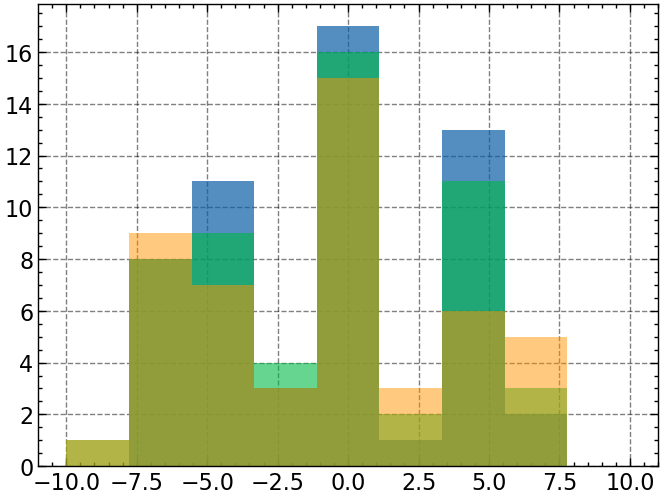

In [74]:
bins = np.linspace(-10, 10, 10)
plt.hist(north_matched['MAG_G']-south_matched['MAG_G'],alpha=0.7,bins=bins)
plt.hist(north_matched['MAG_R']-south_matched['MAG_R'],alpha=0.6,bins=bins)
plt.hist(north_matched['MAG_Z']-south_matched['MAG_Z'],alpha=0.5,bins=bins)

In [48]:
south_matched

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32
321701,3533m017,4364,SER,353.3896522612403,-1.7192790281777435,101.27974,248.48582,470.88333,0.89112955,0.9252932,0.95749885,6,5,5,0.011347285,0.006049454,0.0044993497,0.054826558,0.054062728,0.057501595,0.91510904,0.9146512,0.9249026,4.0456457,-0.15441126,0.15895443,17.94442,44.02592,83.429596,18.967005,0,6.0,3.2294004,17.361046,16.427444,15.770562,19.240028,18.306427,17.649546,17.486193,16.511745,15.817717,353.38965226124,-1.71927902818,2015.5,false,FPT,1,1,2842487357964291,0.09620609,0.07752987
337600,0081p012,8050,SER,8.194201013488751,1.1304000981113975,282.6639,613.6446,1083.5574,0.93883246,0.9583738,0.9764983,10,10,9,0.0050392034,0.0032181784,0.0032557137,0.011197222,0.005416212,0.0073482497,0.99956477,0.99733615,0.9019698,3.390832,-0.06564967,0.09185319,44.271885,96.11133,169.71083,0.0,4096,4.471564,3.0273564,16.303293,15.484045,14.887049,18.31615,17.4969,16.899904,16.371822,15.530208,14.91287,8.19420101349,1.13040009811,2015.5,false,FPT,1,1,2842554043203585,0.04029561,0.032543976
338165,1493p012,2761,SER,149.382089304721,1.2125320480444746,43.29452,101.17235,186.35394,0.94159174,0.9602702,0.9775787,4,4,4,0.00090791663,0.0005732393,0.00018440443,0.009941749,0.022605335,0.0043844483,0.99825424,0.99820036,0.99814475,1.3745339,0.17364076,-0.21564259,15.1459255,35.393597,65.19308,19.206274,0,6.0,1.0344127,18.343575,17.443329,16.799532,19.483917,18.583672,17.939877,18.408916,17.487345,16.824154,149.38208930472,1.21253204804,2015.5,false,FPT,1,1,2842556412985352,0.08152351,0.06283214
338982,3536p012,4476,SER,353.6670742016937,1.2198105648809412,234.07729,551.56134,1087.4148,0.890315,0.9247234,0.957169,9,7,7,0.00046721153,0.0005286962,0.0006272706,0.061941084,0.1090736,0.10028635,0.9997696,0.99990577,0.9992651,6.077514,0.01988919,0.3899391,19.293358,45.461353,89.62802,0.0,4096,2.7886279,4.0239725,16.45046,15.561045,14.861483,19.16034,18.270924,17.571362,16.576601,15.646015,14.909011,353.66707420169,1.21981056488,2015.5,false,FPT,1,1,2842559839731715,0.072254665,0.04204823
492330,1186p292,2352,SER,118.58733000494766,29.324050387417596,36.952625,74.602425,125.58126,0.8509667,0.89699084,0.94100475,4,3,3,0.00044567525,0.00040705295,0.00067686226,0.014476819,0.22465028,0.013815477,0.80276793,0.9986579,0.99866813,1.4479917,0.037859198,-0.016786536,10.928158,22.062494,37.138687,19.670246,0,5.4597225,1.3892167,18.405668,17.700089,17.186666,19.728415,19.022833,18.509413,18.580887,17.818117,17.252687,118.58733000495,29.32405038742,2015.5,false,FPT,1,1,2843203027861517,0.07632959,0.03508413
492509,1698p292,2825,SER,169.8633639715861,29.37269224385646,353.95206,783.73737,1346.9043,0.95077616,0.9665697,0.9811607,2,2,3,0.001480636,0.0004338641,0.0034419436,0.06708329,0.043621756,0.043035787,0.54069495,0.7119701,0.743106,5.084306,0.047587782,0.14531504,38.844883,86.01218,147.8176,0.0,4096,4.237051,4.3581214,16.072834,15.227655,14.656008,18.47186,17.626682,17.055035,16.12764,15.264573,14.676658,169.86336397159,29.37269224386,2015.5,false,FPT,1,1,2843203778641928,0.061221197,0.050501846
493920,2139p295,2551,SER,213.9585579099816,29.44972

In [54]:
south_matched

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32
321701,3533m017,4364,SER,353.3896522612403,-1.7192790281777435,101.27974,248.48582,470.88333,0.89112955,0.9252932,0.95749885,6,5,5,0.011347285,0.006049454,0.0044993497,0.054826558,0.054062728,0.057501595,0.91510904,0.9146512,0.9249026,4.0456457,-0.15441126,0.15895443,17.94442,44.02592,83.429596,18.967005,0,6.0,3.2294004,17.361046,16.427444,15.770562,19.240028,18.306427,17.649546,17.486193,16.511745,15.817717,353.38965226124,-1.71927902818,2015.5,false,FPT,1,1,2842487357964291,0.09620609,0.07752987
337600,0081p012,8050,SER,8.194201013488751,1.1304000981113975,282.6639,613.6446,1083.5574,0.93883246,0.9583738,0.9764983,10,10,9,0.0050392034,0.0032181784,0.0032557137,0.011197222,0.005416212,0.0073482497,0.99956477,0.99733615,0.9019698,3.390832,-0.06564967,0.09185319,44.271885,96.11133,169.71083,0.0,4096,4.471564,3.0273564,16.303293,15.484045,14.887049,18.31615,17.4969,16.899904,16.371822,15.530208,14.91287,8.19420101349,1.13040009811,2015.5,false,FPT,1,1,2842554043203585,0.04029561,0.032543976
338165,1493p012,2761,SER,149.382089304721,1.2125320480444746,43.29452,101.17235,186.35394,0.94159174,0.9602702,0.9775787,4,4,4,0.00090791663,0.0005732393,0.00018440443,0.009941749,0.022605335,0.0043844483,0.99825424,0.99820036,0.99814475,1.3745339,0.17364076,-0.21564259,15.1459255,35.393597,65.19308,19.206274,0,6.0,1.0344127,18.343575,17.443329,16.799532,19.483917,18.583672,17.939877,18.408916,17.487345,16.824154,149.38208930472,1.21253204804,2015.5,false,FPT,1,1,2842556412985352,0.08152351,0.06283214
338982,3536p012,4476,SER,353.6670742016937,1.2198105648809412,234.07729,551.56134,1087.4148,0.890315,0.9247234,0.957169,9,7,7,0.00046721153,0.0005286962,0.0006272706,0.061941084,0.1090736,0.10028635,0.9997696,0.99990577,0.9992651,6.077514,0.01988919,0.3899391,19.293358,45.461353,89.62802,0.0,4096,2.7886279,4.0239725,16.45046,15.561045,14.861483,19.16034,18.270924,17.571362,16.576601,15.646015,14.909011,353.66707420169,1.21981056488,2015.5,false,FPT,1,1,2842559839731715,0.072254665,0.04204823
492330,1186p292,2352,SER,118.58733000494766,29.324050387417596,36.952625,74.602425,125.58126,0.8509667,0.89699084,0.94100475,4,3,3,0.00044567525,0.00040705295,0.00067686226,0.014476819,0.22465028,0.013815477,0.80276793,0.9986579,0.99866813,1.4479917,0.037859198,-0.016786536,10.928158,22.062494,37.138687,19.670246,0,5.4597225,1.3892167,18.405668,17.700089,17.186666,19.728415,19.022833,18.509413,18.580887,17.818117,17.252687,118.58733000495,29.32405038742,2015.5,false,FPT,1,1,2843203027861517,0.07632959,0.03508413
492509,1698p292,2825,SER,169.8633639715861,29.37269224385646,353.95206,783.73737,1346.9043,0.95077616,0.9665697,0.9811607,2,2,3,0.001480636,0.0004338641,0.0034419436,0.06708329,0.043621756,0.043035787,0.54069495,0.7119701,0.743106,5.084306,0.047587782,0.14531504,38.844883,86.01218,147.8176,0.0,4096,4.237051,4.3581214,16.072834,15.227655,14.656008,18.47186,17.626682,17.055035,16.12764,15.264573,14.676658,169.86336397159,29.37269224386,2015.5,false,FPT,1,1,2843203778641928,0.061221197,0.050501846
493920,2139p295,2551,SER,213.9585579099816,29.44972

In [11]:
table_vizier_matched=vstack([table_vizier_north,table_vizier_south])
print('length of total matched:',len(table_vizier_matched))

print('unique length of matched:',len(unique(table_vizier_matched, keys=['BRICKID', 'OBJID'])))



length of total matched: 439722
unique length of matched: 427273


In [33]:
from collections import OrderedDict
e1, e2 = table_vizier_matched['SHAPE_E1'], table_vizier_matched['SHAPE_E2']
epsilon = np.sqrt(e1**2 + e2**2)
bba = (1 - epsilon) / (1 + epsilon)
table_vizier_matched['bba'] = bba
# Define all individual cuts
cuts_dict = OrderedDict({
    'MAG_R < 18': table_vizier_matched['MAG_R'] < 18,
    'G - R > 0.68': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) > 0.68,
    'G - R > 1.3*(R - Z) - 0.05': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) > (1.3 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.05),
    'G - R < 2.0*(R - Z) - 0.15': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) < (2.0 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.15),
    'R_CIRC > 0': table_vizier_matched['R_CIRC'] > 0,
    '1 - bba < 0.7': (1 - table_vizier_matched['bba']) < 0.7,
    'Sérsic condition': ((table_vizier_matched['TYPE'] == 'SER') & (table_vizier_matched['SERSIC'] > 2.5)) | (table_vizier_matched['TYPE'] == 'DEV'),
    'Z_PHOT_MEDIAN < 0.15': table_vizier_matched['Z_PHOT_MEDIAN'] < 0.15,
    'Z_PHOT_L95 < 0.1': table_vizier_matched['Z_PHOT_L95'] < 0.1,
})

total = len(table_vizier_matched)
current_mask = np.ones(total, dtype=bool)
print(f"Initial: {total} rows")

for name, cond in cuts_dict.items():
    current_mask &= cond
    passed = np.count_nonzero(current_mask)
    print(f"After '{name}': {passed} rows (lost {total - passed})")

Initial: 439722 rows
After 'MAG_R < 18': 427707 rows (lost 12015)
After 'G - R > 0.68': 427560 rows (lost 12162)
After 'G - R > 1.3*(R - Z) - 0.05': 427451 rows (lost 12271)
After 'G - R < 2.0*(R - Z) - 0.15': 427301 rows (lost 12421)
After 'R_CIRC > 0': 427296 rows (lost 12426)
After '1 - bba < 0.7': 427296 rows (lost 12426)
After 'Sérsic condition': 427294 rows (lost 12428)
After 'Z_PHOT_MEDIAN < 0.15': 424373 rows (lost 15349)
After 'Z_PHOT_L95 < 0.1': 418126 rows (lost 21596)


In [34]:
table_vizier_matched

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95,bba
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32,float32
321728,0001m015,1509,EXP,0.24291697772290713,-1.508787688291821,0.0,0.0,9.822458,0.89668083,0.9291721,0.95974195,0,0,1,0.0,0.0,0.10770063,0.0,0.0,0.3521755,0.0,0.0,0.99725485,0.7351449,-0.41421366,-0.26387918,0.0,0.0,4.976246,0.0,0,1.0,0.429458,22.5,22.5,19.974836,22.5,22.5,20.71313,22.5,22.5,20.01945,0.0467062654,-1.51237003653,2015.5,false,FPT,1,1,2842487471210497,-99.0,-99.0,0.3412679
321732,0011m015,463,PSF,1.0755497916220742,-1.4396721361483036,0.0,0.0,230.66846,0.90275496,0.93340725,0.9621864,0,0,1,0.0,0.0,0.58912534,0.0,0.0,0.9344852,0.0,0.0,0.9983388,0.0,0.0,0.0,0.0,0.0,179.29744,17.06188,144,0.0,0.0,22.5,22.5,16.550678,22.5,22.5,16.824211,22.5,22.5,16.59253,1.01155418239,-1.50937604368,2015.5,false,FPT,1,1,2842487487987716,-99.0,-99.0,1.0
321738,0026m015,210,REX,2.5391266461237265,-1.4849805354673682,0.0,0.0,2.441751,0.8865555,0.92209125,0.9556441,0,0,1,0.0,0.0,0.0,0.0,0.0,0.01537407,0.0,0.0,0.98964405,0.3046625,0.0,0.0,0.0,0.0,1.5810041,0.0,0,1.0,0.3046625,22.5,22.5,21.481487,22.5,22.5,21.953407,22.5,22.5,21.530746,2.50432259635,-1.5316114018,2015.5,false,FPT,1,1,2842487513153538,-99.0,-99.0,1.0
321738,0026m015,700,PSF,2.6591789385529356,-1.5242404474403723,0.0,0.0,1.3714671,0.8790602,0.9168327,0.9525918,0,0,1,0.0,0.0,0.50113946,0.0,0.0,0.038254134,0.0,0.0,0.62225354,0.0,0.0,0.0,0.0,0.0,1.0664092,0.0,0,0.0,0.0,22.5,22.5,22.104303,22.5,22.5,22.377457,22.5,22.5,22.157036,2.51834657348,-1.61051850759,2015.5,false,FPT,1,1,2842487513153537,-99.0,-99.0,1.0
321739,0028m015,397,REX,2.810094503269215,-1.5069730732401425,0.0,0.0,2.1143682,0.90250355,0.9332322,0.9620854,0,0,1,0.0,0.0,0.002223227,0.0,0.0,0.022136113,0.0,0.0,1.0027324,0.35606098,0.0,0.0,0.0,0.0,1.2920444,0.0,0,1.0,0.35606098,22.5,22.5,21.645082,22.5,22.5,22.17984,22.5,22.5,21.687048,2.75891979166,-1.47508671757,2015.5,false,FPT,1,1,2842487517347842,-99.0,-99.0,1.0
321741,0033m015,259,PSF,3.3058806927063213,-1.470861459838108,0.0,0.0,2.289185,0.90489286,0.93489575,0.96304435,0,0,1,0.0,0.0,0.0,0.0,0.0,0.026847243,0.0,0.0,0.9792101,0.0,0.0,0.0,0.0,0.0,1.7831423,0.0,0,0.0,0.0,22.5,22.5,21.559914,22.5,22.5,21.83115,22.5,22.5,21.600798,3.25427623818,-1.51804635107,2015.5,false,FPT,1,1,2842487525736450,-99.0,-99.0,1.0
321741,0033m015,362,PSF,3.3294463851684735,-1.4991197181371816,0.0,0.0,1.3909171,0.9070778,0.93641573,0.9639199,0,0,1,0.0,0.0,0.0,0.0,0.0,0.06375368,0.0,0.0,0.969827,0.0,0.0,0.0,0.0,0.0,1.0817928,0.0,0,0.0,0.0,22.5,22.5,22.101849,22.5,22.5,22.374743,22.5,22.5,22.141747,3.25712827247,-1.56766213698,2015.5,false,FPT,1,1,2842487525736448,-99.0,-99.0,1.0
321745,0043m015,587,EXP,4.3959341166034065,-1.3978496162263625,0.0,0.0,14.80098,0.87019545,0.91059434,0.94896084,0,0,1,0.0,0.0,0.0,0.0,0.0,0.013740842,0.0,0.0,0.9947876,0.8879204,0.18701832,0.07083202,0.0,0.0,5.6335177,0.0,0,1.0,0.7249971,22.5,22.5,19.517395,22.5,22.5,20.566172,22.5,22.5,19.574274,4.26457042671,-1.43405349224,2015.5,false,FPT,1,1,2842487542513673,-99.0,-99.0,0.6666909
321745,0043m015,958,PSF,4.484144599446136,-1.5124100046001863,0.0,0.0,1.699444,0.8346125,0.8853418,0.93414944,

In [24]:
#table_nonmask=table_vizier_matched[table_vizier_matched['MAG_R']>18]
#np.log10(table_nonmask['FLUX_R']/table_nonmask['MW_TRANSMISSION_R'])

/tmp/ipykernel_3351945/624491056.py:2: RuntimeWarning: divide by zero encountered in log10
  np.log10(table_nonmask['FLUX_R']/table_nonmask['MW_TRANSMISSION_R'])
/tmp/ipykernel_3351945/624491056.py:2: RuntimeWarning: invalid value encountered in log10
  np.log10(table_nonmask['FLUX_R']/table_nonmask['MW_TRANSMISSION_R'])


-inf
-inf
-inf
-inf
-inf
-inf
-inf
-inf
-inf
-inf
-inf


In [35]:
total = len(table_vizier_matched)
current_mask = np.ones(total, dtype=bool)
previous_count = total

print(f"{'Step':<35} | {'Remaining':>9} | {'Lost':>6} | {'Cumulative Lost':>16}")
print("-" * 70)

cumulative_lost = 0
for name, cond in cuts_dict.items():
    current_mask &= cond
    current_count = np.count_nonzero(current_mask)
    step_lost = previous_count - current_count
    cumulative_lost += step_lost
    print(f"{name:<35} | {current_count:>9} | {step_lost:>6} | {cumulative_lost:>16}")
    previous_count = current_count

Step                                | Remaining |   Lost |  Cumulative Lost
----------------------------------------------------------------------
MAG_R < 18                          |    427707 |  12015 |            12015
G - R > 0.68                        |    427560 |    147 |            12162
G - R > 1.3*(R - Z) - 0.05          |    427451 |    109 |            12271
G - R < 2.0*(R - Z) - 0.15          |    427301 |    150 |            12421
R_CIRC > 0                          |    427296 |      5 |            12426
1 - bba < 0.7                       |    427296 |      0 |            12426
Sérsic condition                    |    427294 |      2 |            12428
Z_PHOT_MEDIAN < 0.15                |    424373 |   2921 |            15349
Z_PHOT_L95 < 0.1                    |    418126 |   6247 |            21596


In [ ]:

cuts = (
			(table_vizier_matched['MAG_R'] < 18) &
			((table_vizier_matched['MAG_G'] -table_vizier_matched['MAG_R']) > 0.68) &
			((table_vizier_matched['MAG_G']- table_vizier_matched['MAG_R']) > (1.3 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.05)) &
			((table_vizier_matched['MAG_G']- table_vizier_matched['MAG_R']) < (2.0 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.15)) &
			(table_vizier_matched['R_CIRC']> 0) &
			((1 -table_vizier_matched['bba']) < 0.7) &
			(((table_vizier_matched['TYPE'] == 'SER') & (table_vizier_matched['SERSIC'] > 2.5)) | (table_vizier_matched['TYPE'] == 'DEV')) &
			(table_vizier_matched['Z_PHOT_MEDIAN'] < 0.15) &
			(table_vizier_matched['Z_PHOT_L95'] < 0.1)
		)
table_vizier_matched[cuts]

unique_rows = unique(table_vizier_matched[cuts], keys=['BRICKID', 'OBJID'])
print(len(table_vizier_matched[cuts]), "rows after cuts")
print(len(unique_rows), "unique rows after FP cuts")
#unique_rows

#nonmask=~mask
#print(unique_rows[nonmask])

mask = ~np.any([col == -99 for col in unique_rows.itercols()], axis=0)
unique_rows = unique_rows[mask]
#mask = (unique_rows['Z_PHOT_MEDIAN'] != -99) & (unique_rows['Z_PHOT_L95'] != -99)
#unique_rows = unique_rows[mask]
#print(len(unique_rows), "rows after removing -99 values")
Mask_unique_rows=BGS_mask(unique_rows)
print('length after applying BGS cuts:',len(unique_rows[Mask_unique_rows]))
final_unique_rows=unique_rows[Mask_unique_rows]

418126 rows after cuts
418113 unique rows after FP cuts
length after applying BGS cuts: 417308


In [27]:
common = join(
    table_F,
    table_FP,
    keys=[  'BRICKID','OBJID','BRICKNAME'],
    join_type='inner'
)

NameError: name 'table_F' is not defined

In [ ]:
#table_FP[(table_FP['BRICKID']==321728) &  (table_FP['OBJID']==1509)]

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (2894280986.py, line 1)

In [ ]:
bad_mask = (
    (table_vizier_matched['Z_PHOT_MEDIAN'] == -99) |
    (table_vizier_matched['FLUX_G'] == 0) |
    (table_vizier_matched['FLUX_R'] == 0) |
    (table_vizier_matched['FLUX_Z'] == 0)
)
bad_table_vizier=table_vizier_matched[bad_mask]


BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95,bba
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32,float32
321728,0001m015,1509,EXP,0.24291697772290713,-1.508787688291821,0.0,0.0,9.822458,0.89668083,0.9291721,0.95974195,0,0,1,0.0,0.0,0.10770063,0.0,0.0,0.3521755,0.0,0.0,0.99725485,0.7351449,-0.41421366,-0.26387918,0.0,0.0,4.976246,0.0,0,1.0,0.429458,22.5,22.5,19.974836,22.5,22.5,20.71313,22.5,22.5,20.01945,0.0467062654,-1.51237003653,2015.5,false,FPT,1,1,2842487471210497,-99.0,-99.0,0.3412679
321732,0011m015,463,PSF,1.0755497916220742,-1.4396721361483036,0.0,0.0,230.66846,0.90275496,0.93340725,0.9621864,0,0,1,0.0,0.0,0.58912534,0.0,0.0,0.9344852,0.0,0.0,0.9983388,0.0,0.0,0.0,0.0,0.0,179.29744,17.06188,144,0.0,0.0,22.5,22.5,16.550678,22.5,22.5,16.824211,22.5,22.5,16.59253,1.01155418239,-1.50937604368,2015.5,false,FPT,1,1,2842487487987716,-99.0,-99.0,1.0
321738,0026m015,210,REX,2.5391266461237265,-1.4849805354673682,0.0,0.0,2.441751,0.8865555,0.92209125,0.9556441,0,0,1,0.0,0.0,0.0,0.0,0.0,0.01537407,0.0,0.0,0.98964405,0.3046625,0.0,0.0,0.0,0.0,1.5810041,0.0,0,1.0,0.3046625,22.5,22.5,21.481487,22.5,22.5,21.953407,22.5,22.5,21.530746,2.50432259635,-1.5316114018,2015.5,false,FPT,1,1,2842487513153538,-99.0,-99.0,1.0
321738,0026m015,700,PSF,2.6591789385529356,-1.5242404474403723,0.0,0.0,1.3714671,0.8790602,0.9168327,0.9525918,0,0,1,0.0,0.0,0.50113946,0.0,0.0,0.038254134,0.0,0.0,0.62225354,0.0,0.0,0.0,0.0,0.0,1.0664092,0.0,0,0.0,0.0,22.5,22.5,22.104303,22.5,22.5,22.377457,22.5,22.5,22.157036,2.51834657348,-1.61051850759,2015.5,false,FPT,1,1,2842487513153537,-99.0,-99.0,1.0
321739,0028m015,397,REX,2.810094503269215,-1.5069730732401425,0.0,0.0,2.1143682,0.90250355,0.9332322,0.9620854,0,0,1,0.0,0.0,0.002223227,0.0,0.0,0.022136113,0.0,0.0,1.0027324,0.35606098,0.0,0.0,0.0,0.0,1.2920444,0.0,0,1.0,0.35606098,22.5,22.5,21.645082,22.5,22.5,22.17984,22.5,22.5,21.687048,2.75891979166,-1.47508671757,2015.5,false,FPT,1,1,2842487517347842,-99.0,-99.0,1.0
321741,0033m015,259,PSF,3.3058806927063213,-1.470861459838108,0.0,0.0,2.289185,0.90489286,0.93489575,0.96304435,0,0,1,0.0,0.0,0.0,0.0,0.0,0.026847243,0.0,0.0,0.9792101,0.0,0.0,0.0,0.0,0.0,1.7831423,0.0,0,0.0,0.0,22.5,22.5,21.559914,22.5,22.5,21.83115,22.5,22.5,21.600798,3.25427623818,-1.51804635107,2015.5,false,FPT,1,1,2842487525736450,-99.0,-99.0,1.0
321741,0033m015,362,PSF,3.3294463851684735,-1.4991197181371816,0.0,0.0,1.3909171,0.9070778,0.93641573,0.9639199,0,0,1,0.0,0.0,0.0,0.0,0.0,0.06375368,0.0,0.0,0.969827,0.0,0.0,0.0,0.0,0.0,1.0817928,0.0,0,0.0,0.0,22.5,22.5,22.101849,22.5,22.5,22.374743,22.5,22.5,22.141747,3.25712827247,-1.56766213698,2015.5,false,FPT,1,1,2842487525736448,-99.0,-99.0,1.0
321745,0043m015,587,EXP,4.3959341166034065,-1.3978496162263625,0.0,0.0,14.80098,0.87019545,0.91059434,0.94896084,0,0,1,0.0,0.0,0.0,0.0,0.0,0.013740842,0.0,0.0,0.9947876,0.8879204,0.18701832,0.07083202,0.0,0.0,5.6335177,0.0,0,1.0,0.7249971,22.5,22.5,19.517395,22.5,22.5,20.566172,22.5,22.5,19.574274,4.26457042671,-1.43405349224,2015.5,false,FPT,1,1,2842487542513673,-99.0,-99.0,0.6666909
321745,0043m015,958,PSF,4.484144599446136,-1.5124100046001863,0.0,0.0,1.699444,0.8346125,0.8853418,0.93414944,

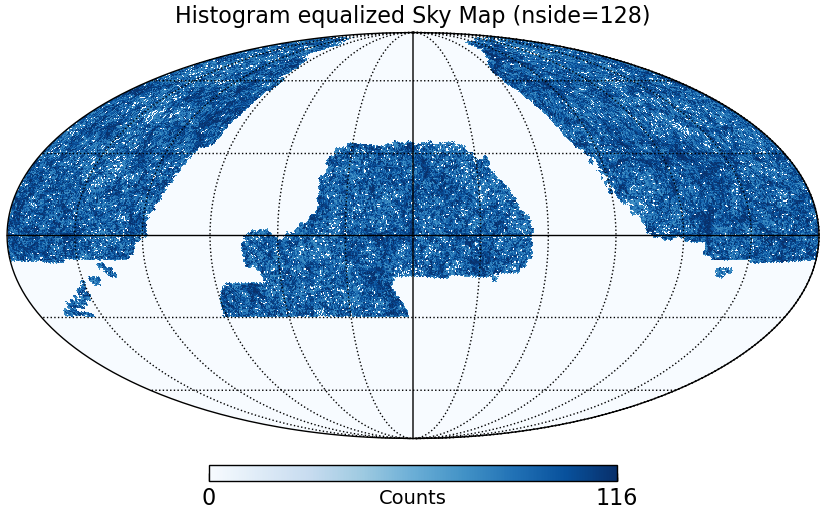

In [ ]:
import healpy as hp
import numpy as np
import healpy.visufunc as hv
ra_array=final_unique_rows['RA']
dec_array=final_unique_rows['DEC']
nside =128
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - dec_array.data)  # theta = 0 at North Pole
phi = np.radians(ra_array.data) 
pix_indices = hp.ang2pix(nside, theta, phi)
hpx_map = np.zeros(npix, dtype=int)

ix,counts=np.unique(pix_indices,return_counts=True)
   # fill the fullsky map
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map,cmap='Blues', unit='Counts',norm='hist',title=f"Histogram equalized Sky Map (nside={nside})")
hp.graticule()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize ,LogNorm
from matplotlib.cm import get_cmap, ScalarMappable

zphot = np.array(final_unique_rows['Z_PHOT_MEDIAN'])
x = final_unique_rows["MAG_R"] - final_unique_rows["MAG_Z"]
y = final_unique_rows["MAG_G"] - final_unique_rows["MAG_R"]

# Create colormap and normalization
valid = zphot != -99
norm = Normalize(vmin=zphot[valid].min(), vmax=zphot[valid].max())
cmap = get_cmap('YlGnBu')

# Compute RGBA colors
colors_all = np.zeros((len(zphot), 4))  # RGBA, shape (N, 4)
colors_all[valid] = cmap(norm(zphot[valid]))  # apply colormap to valid entries
colors_all[~valid] = [0, 0, 0, 1]  # black for zphot == -99

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color=colors_all, alpha=0.9, s=0.1)

plt.xlabel("mag$_R$ - mag$_Z$")
plt.ylabel("mag$_G$ - mag$_R$")
plt.title("Color-Color Scatter Diagram ")
plt.grid(True)

# Colorbar only for valid entries
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="Z_PHOT_MEDIAN")

plt.tight_layout()
plt.show()


NameError: name 'final_unique_rows' is not defined

/tmp/ipykernel_3319101/2829307743.py:5: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Z_PHOT_MEDIAN')


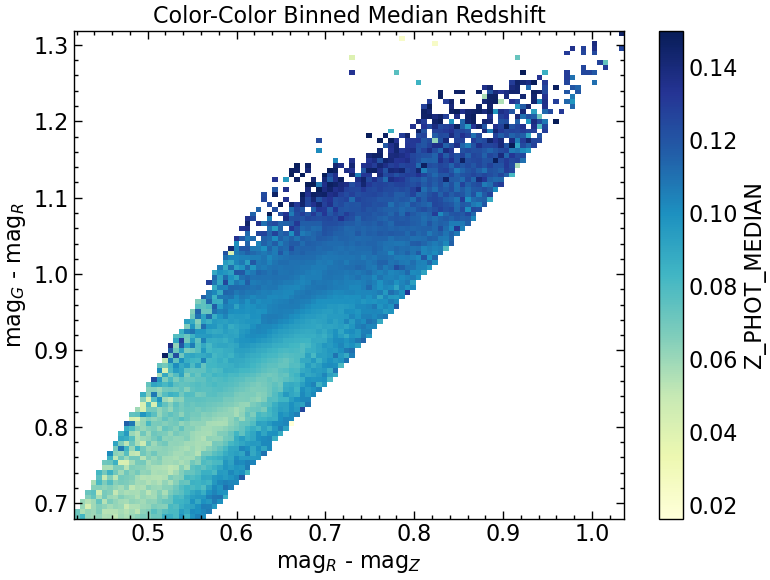

In [ ]:
from scipy.stats import binned_statistic_2d

stat, x_edges, y_edges, _ = binned_statistic_2d(x, y, zphot, statistic='median', bins=100)
plt.imshow(stat.T, origin='lower', aspect='auto', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], cmap='YlGnBu')
plt.colorbar(label='Z_PHOT_MEDIAN')
plt.xlabel("mag$_R$ - mag$_Z$")
plt.ylabel("mag$_G$ - mag$_R$")
plt.title("Color-Color Binned Median Redshift")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
cmap = get_cmap('autumn')

norm = LogNorm(vmin=zphot[valid].min(), vmax=zphot[valid].max())
colors_all[valid] = cmap(norm(zphot[valid]))
colors_all[~valid] = [0, 0, 0, 1]  # black for invalid



In [ ]:
common = join(
    table_vizier_north,
    table_vizier_south,
    keys=[  'BRICKID','OBJID','BRICKNAME'],
    join_type='inner'
)
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color=colors_all, alpha=0.9, s=0.5)

plt.xlabel("MAG_R - MAG_Z")
plt.ylabel("MAG_G - MAG_R")
plt.title("Color-Color Diagram (Log Colormap)")
plt.grid(True)

# Colorbar for valid zphot
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="Z_PHOT_MEDIAN (log scale)")

plt.tight_layout()
plt.show()

NameError: name 'x' is not defined

<Figure size 600x600 with 0 Axes>

In [ ]:
common = join(
    table,
    unique_rows,
    keys=[  'BRICKID','OBJID','BRICKNAME'],
    join_type='inner')

In [ ]:
keys_tab2 = set(zip(table_match_final['BRICKID'], table_match_final['OBJID'], table_match_final['BRICKNAME']))
keys_table = set(zip(final_unique_rows['BRICKID'], final_unique_rows['OBJID'],final_unique_rows['BRICKNAME']))

In [ ]:
#all of keys in unique_rows are in table but not vice versa
unmatched_keys=keys_tab2 - keys_table

In [ ]:
mask = [(brickid, objid,brickname) in unmatched_keys for brickid, objid,brickname in zip(table['BRICKID'], table['OBJID'],table['BRICKNAME'])]
unmatched_rows = table[mask]

In [ ]:

#unmatched_rows
unmatched_rows == unique(unmatched_rows, keys=['BRICKID', 'OBJID','BRICKNAME'])

print(len(unmatched_rows), "unmatched rows")
mask = ~np.any([col == -99 for col in unmatched_rows.itercols()], axis=0)
unmatched_rows = unmatched_rows[mask]
unmatched_rows

13441 unmatched rows


BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
326196,0371m007,3000,SER,37.17307614987316,-0.8359418184863707,26.20573,62.307278,111.883766,0.9030684,0.93362564,0.9623123,3,4,6,0.0022328892,0.0017639098,0.0012555281,0.0031341158,0.0033814926,0.0035261512,0.99995965,0.9999485,0.998597,0.9436603,-0.06782208,-0.05032607,9.370341,22.279114,40.0061,19.861435,0,3.6413803,0.86706173,18.843311,17.939085,17.336372,19.959913,19.055687,18.452974,18.95401,18.013653,17.378082,0.07897235,0.057566054
326196,0371m007,3058,SER,37.17605430672796,-0.8465078483625974,83.86569,229.5902,501.12552,0.90314215,0.93367696,0.9623419,3,4,4,0.12423383,0.10137634,0.107079454,0.020712847,0.020735841,0.021967635,0.99778974,0.9977973,0.6971285,3.1320574,-0.060779147,0.036701065,12.875178,35.24701,76.93349,0.0,4096,4.113088,2.9170415,17.58043,16.523108,15.708457,19.615007,18.557686,17.743034,17.69104,16.597616,15.7501335,0.09622078,0.06397838
326196,0371m007,3091,SER,37.177657616055335,-0.8492741187278495,325.67032,709.0457,1255.1355,0.9031664,0.9336938,0.9623516,3,4,4,0.048393108,0.05777874,0.09788793,0.088571526,0.088418484,0.07774617,0.94878775,0.9482651,0.602127,7.264535,0.016855637,-0.041289773,17.04098,37.101425,65.67604,0.0,4096,3.1757193,6.9474654,16.107473,15.298825,14.711608,19.310682,18.502035,17.914818,16.218054,15.373314,14.753273,0.06491999,0.03911662
326196,0371m007,3889,SER,37.21882590865914,-0.7677824417206347,116.69464,275.30984,491.5747,0.9107296,0.9389536,0.9653802,3,4,7,0.021018406,0.01351206,0.00847735,0.011830271,0.012454596,0.049692936,0.782767,0.70791185,0.97248423,2.1300552,0.12522282,-0.27506393,28.662136,67.62065,120.73889,18.60417,16,4.2346907,1.5592107,17.230846,16.332054,15.732773,18.755201,17.856411,17.257128,17.332373,16.400444,15.771027,0.07522254,0.06129543
330518,0376p000,2188,SER,37.63279842543019,-0.0019545315565760286,129.41557,312.4884,555.1835,0.93472445,0.9555469,0.9748862,2,4,5,2.8071702,0.26776132,0.32795915,0.235933,0.70116514,0.11472735,0.66577125,0.798964,0.9986286,2.9530487,-0.36729765,0.04423549,30.625507,73.94872,131.38123,18.395773,2072,6.0,2.0026488,17.146742,16.213545,15.611294,18.7115,17.778303,17.176052,17.220034,16.262915,15.638908,0.09018374,0.04117998
330518,0376p000,2694,SER,37.66204658050864,-0.02072201115528884,55.177284,111.304146,191.9303,0.9329061,0.9542944,0.97417116,3,5,4,0.0073353946,0.002340394,0.00096253474,0.009537279,0.008925471,0.009590004,0.99465364,0.9954977,0.9958475,1.369642,0.15997021,0.112553276,18.384657,37.085705,63.949734,18.938347,0,5.672823,1.1234426,18.070194,17.332928,16.76373,19.263456,18.52619,17.956991,18.1456,17.38372,16.792141,0.14954486,0.09452175
326197,0373m007,433,SER,37.274392030708654,-0.8544710044826774,140.88066,294.3703,487.85464,0.9090317,0.937774,0.96470165,3,5,4,0.0029706631,0.0027493846,0.0007871838,0.05132572,0.083003536,0.048110005,0.9640522,0.9644914,0.6451703,3.6648996,-0.09353421,-0.047296334,24.858915,51.942734,86.08376,18.727901,0,6.0,3.298944,17.024319,16.25801,15.740256,18.907742,18.141434,17.62368,17.12787,16.327765,15.779274,0.03089841,0.02015233
326197,0373m007,1542,DEV,37.34321949535508,-0.646802966244248,32.710278,83.6405,159.03944,0.91050535,0.93879783,0.96529067,3,5,5,0.04235444,0.03904382,0.036861405,6.0492923e-0

492937

In [ ]:
def prepare_coords(ra_deg, dec_deg):
    ra_rad = np.radians(ra_deg)
    ra_rad = np.remainder(ra_rad + 2*np.pi, 2*np.pi)  # Normalize 
    ra_rad[ra_rad > np.pi] -= 2*np.pi                # Shift 
    ra_rad = -ra_rad                                  # Flip 
    dec_rad = np.radians(dec_deg)
    return ra_rad, dec_rad    
unmatched_ra, unmatched_dec = prepare_coords(unmatched_rows['RA'], unmatched_rows['DEC'])
#ra_n, dec_n = prepare_coords(unmatched_rows['RA'], unmatched_rows['DEC'])


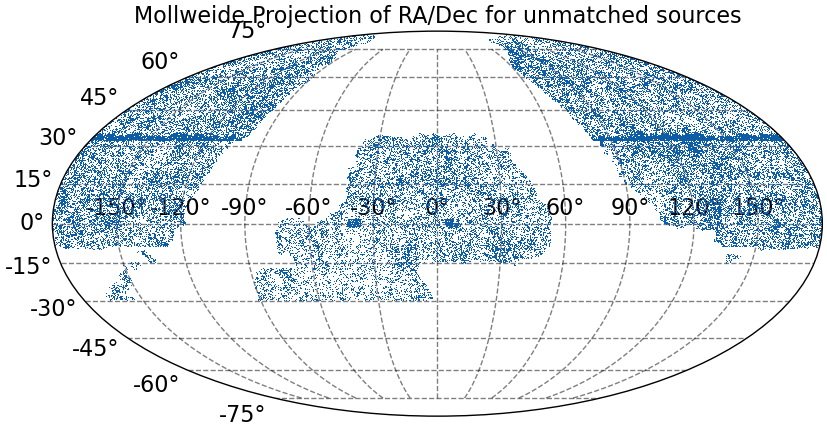

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')
ax.plot(unmatched_ra, unmatched_dec, ',')
#ax.plot(ra_n, dec_n, ',')
ax.grid(True)
plt.title('Mollweide Projection of RA/Dec for unmatched sources')
plt.show()

In [ ]:
unmatched_ra

-0.6487925719098637
-0.6488445505526208
-0.6488725335793113
-0.6495910558326727
-0.6573267158693472
-0.6505608676150016
-0.6517621334888819
-0.6459997471612589
-0.6463937417812273
-0.6471009848742897
-0.6593724620141321


/tmp/ipykernel_3319101/364697140.py:26: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(sm, label="Z_PHOT_MEDIAN")


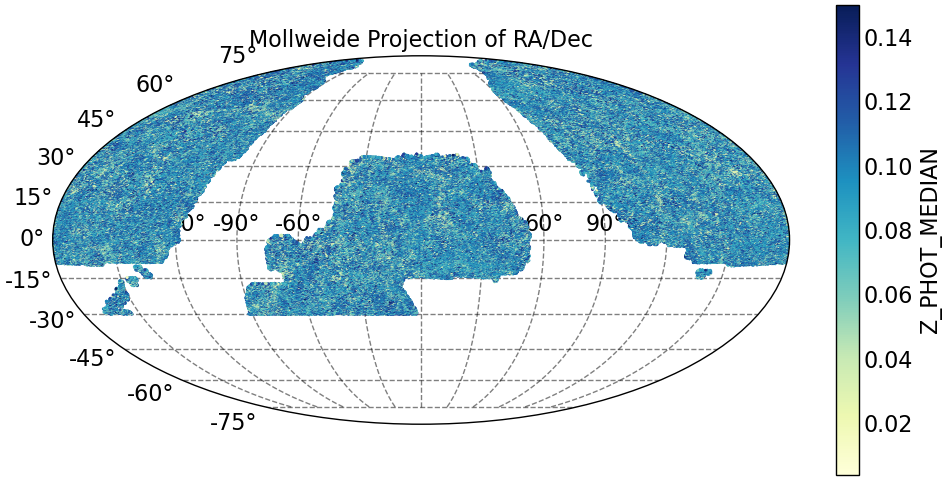

In [ ]:
from matplotlib.colors import Normalize   
unique_ra, unique_dec = prepare_coords(unique_rows['RA'], unique_rows['DEC'])
zphot = np.array(unique_rows['Z_PHOT_MEDIAN'])


# Create colormap and normalization
valid = zphot != -99
norm = Normalize(vmin=zphot[valid].min(), vmax=zphot[valid].max())
cmap = get_cmap('YlGnBu')

# Compute RGBA colors
colors_all = np.zeros((len(zphot), 4))  # RGBA, shape (N, 4)
colors_all[valid] = cmap(norm(zphot[valid]))  # apply colormap to valid entries
colors_all[~valid] = [0, 0, 0, 1]  # black for zphot == -99

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

sc = ax.scatter(unique_ra, unique_dec, c=colors_all, s=1, cmap=cmap, norm=norm)
#ax.plot(ra_n, dec_n, ',')
ax.grid(True)
plt.title('Mollweide Projection of RA/Dec')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="Z_PHOT_MEDIAN")

plt.tight_layout()
plt.show()

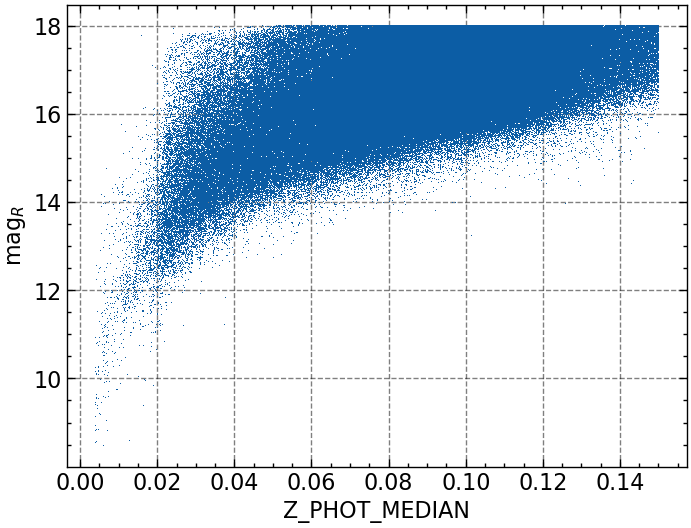

In [ ]:
plt.plot(zphot.data,mag_r.data,',')
plt.xlabel('Z_PHOT_MEDIAN')
plt.ylabel('mag$_R$')
plt.show()

/tmp/ipykernel_3319101/3281312334.py:26: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(sm, label="MAG_R")


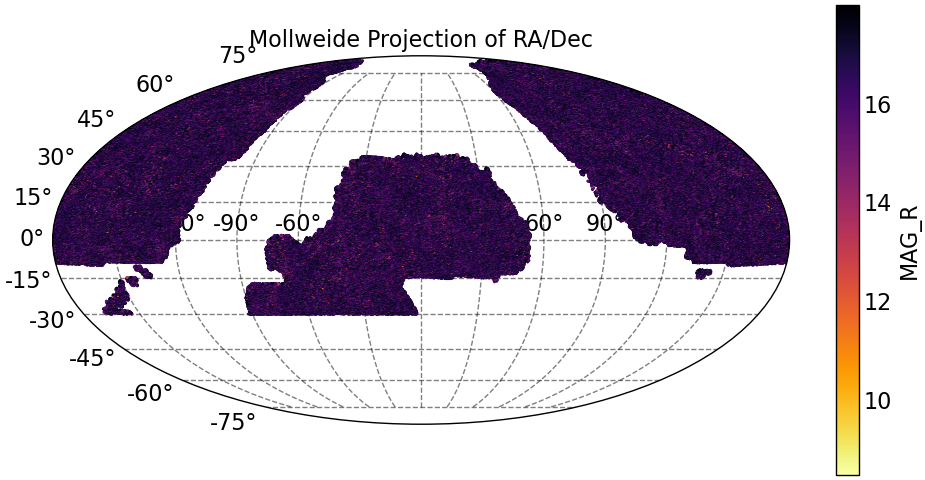

In [ ]:
from matplotlib.colors import Normalize   
unique_ra, unique_dec = prepare_coords(unique_rows['RA'], unique_rows['DEC'])
mag_r = np.array(unique_rows['MAG_R'])


# Create colormap and normalization
valid = zphot != -99
norm = Normalize(vmin=mag_r[valid].min(), vmax=mag_r[valid].max())
cmap = get_cmap('inferno_r')

# Compute RGBA colors
colors_all = np.zeros((len(mag_r), 4))  # RGBA, shape (N, 4)
colors_all[valid] = cmap(norm(mag_r[valid]))  # apply colormap to valid entries
colors_all[~valid] = [0, 0, 0, 1]  # black for mag_r == -99

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

sc = ax.scatter(unique_ra, unique_dec, c=colors_all, s=1, cmap=cmap, norm=norm)
#ax.plot(ra_n, dec_n, ',')
ax.grid(True)
plt.title('Mollweide Projection of RA/Dec')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="MAG_R")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3138578/4088091080.py:27: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(sm, label="Z_PHOT_MEDIAN")


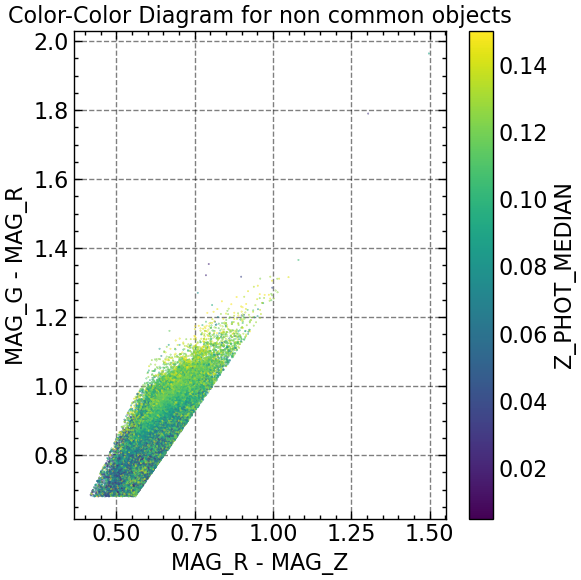

In [ ]:


zphot = np.array(unmatched_rows['Z_PHOT_MEDIAN'])
x = unmatched_rows["MAG_R"] - unmatched_rows["MAG_Z"]
y = unmatched_rows["MAG_G"] - unmatched_rows["MAG_R"]

# Create colormap and normalization
valid = zphot != -99
norm = Normalize(vmin=zphot[valid].min(), vmax=zphot[valid].max())
cmap = get_cmap('viridis')

# Compute RGBA colors
colors_all = np.zeros((len(zphot), 4))  # RGBA, shape (N, 4)
colors_all[valid] = cmap(norm(zphot[valid]))  # apply colormap to valid entries
colors_all[~valid] = [0, 0, 0, 1]  # black for zphot == -99

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color=colors_all, alpha=0.9, s=0.1)

plt.xlabel("MAG_R - MAG_Z")
plt.ylabel("MAG_G - MAG_R")480881
plt.title("Color-Color Diagram for non common objects")
plt.grid(True)

# Colorbar only for valid entries
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="Z_PHOT_MEDIAN")
norm(zphot[valid]).data
plt.tight_layout()
plt.show()


In [ ]:
mask_unique=BGS_mask(unique_rows)

In [ ]:
unique_rows[mask_unique]

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95,bba
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32,float32
165253,0027m300,965,SER,2.62843215831155,-29.91925624962128,29.589272,69.85892,120.78643,0.96353453,0.97528774,0.9861009,4,3,3,0.008256373,0.0038269241,0.0022503377,0.1046411,0.007468015,0.008222433,0.9908769,0.9793203,0.952676,1.439051,0.056706924,0.4707824,10.633193,25.104483,43.40578,19.594368,0,5.365548,0.8594418,18.781832,17.862278,17.279758,19.89301,18.973454,18.390934,18.822165,17.889446,17.294954,2.62843215831,-29.91925624962,2015.5,false,FPT,1,1,2841831167492096,0.11925707,0.07404,0.3566815
165253,0027m300,8018,SER,2.863540922350348,-29.985583424278076,97.60628,213.71559,357.0383,0.9634142,0.97520566,0.98605454,5,4,4,0.0039558485,0.0015543617,0.001746305,0.015935633,0.015104101,0.014372644,0.71346325,0.7980461,0.79839915,2.8665063,0.006381261,0.20037729,18.40419,40.297226,67.321495,19.03229,0,4.3995013,2.3393254,17.485838,16.64815,16.102964,19.297241,18.459553,17.914368,17.526306,16.67541,16.118214,2.86354092235,-29.98558342428,2015.5,false,FPT,1,1,2841831167492097,0.08216938,0.05233359,0.66600186
165254,0030m300,2729,SER,2.959861190581655,-29.976833409107144,133.6931,302.06693,545.4084,0.9645446,0.9759763,0.9864903,6,5,5,0.009309506,0.009026461,0.008460421,0.035788488,0.054935064,0.035521712,0.6832331,0.6349298,0.78917336,5.465792,0.13749963,-0.17273739,9.752995,22.035969,39.78788,0.0,4096,2.5810404,4.366806,17.145533,16.27334,15.643427,19.98796,19.115768,18.485855,17.184727,16.299742,15.6581955,2.95986119058,-29.97683340911,2015.5,false,FPT,1,1,2841831171686402,0.10260826,0.079693824,0.63829523
165255,0033m300,2437,SER,3.242204419597018,-29.965335681021642,89.15787,202.9126,363.35596,0.96199393,0.974237,0.9855066,10,8,8,0.007147767,0.0075664036,0.007917962,0.010226642,0.0061172945,0.0051263277,0.9090077,0.8885625,0.88719994,2.9307039,0.36358386,0.14786936,19.57327,44.546417,79.76935,0.0,4096,4.886093,1.9357351,17.582531,16.703388,16.083317,19.228771,18.349628,17.729559,17.624601,16.731728,16.099169,3.2422044196,-29.96533568102,2015.5,false,FPT,1,1,2841831175880704,0.07002529,0.041350946,0.43626264
165257,0038m300,6111,SER,3.919789628016901,-29.961178984068038,74.51839,149.5096,240.37823,0.9498003,0.9659014,0.98078114,11,9,9,0.014173677,0.010118711,0.0141074285,0.077337496,0.07685828,0.084938005,0.8987434,0.97904754,0.8051987,5.2499204,0.35237825,0.075496554,7.746992,15.543139,24.989918,0.0,0,3.20539,3.5998638,17.763422,17.02566,16.526691,20.221249,19.483484,18.984518,17.819342,17.063328,16.547762,3.91978962802,-29.96117898407,2015.5,false,FPT,1,1,2841831184269314,0.093006395,0.044483088,0.4701828
165258,0041m300,690,SER,4.048538258520457,-29.972884287167602,358.9719,788.084,1381.0511,0.9535388,0.9684607,0.9822339,14,11,9,0.00044445426,0.00031957513,0.00036906582,0.05397016,0.05349998,0.058807805,0.8793855,0.8675587,0.8081867,9.583365,-0.03486811,0.26829654,22.80636,50.068897,87.74155,0.0,4096,4.0432916,7.261371,16.060696,15.223773,14.6300125,19.053205,18.216286,17.622524,16.112349,15.258569,14.649475,4.04853825852,-29.97288428717,2015.5,false,FPT,1,1,2841831188463616,0.070030585,0.044504732,0.574117

In [ ]:
mask_unmatched=BGS_mask(unmatched_rows)
unmatched_rows[mask_unmatched]

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
326196,0371m007,3000,SER,37.17307614987316,-0.8359418184863707,26.20573,62.307278,111.883766,0.9030684,0.93362564,0.9623123,3,4,6,0.0022328892,0.0017639098,0.0012555281,0.0031341158,0.0033814926,0.0035261512,0.99995965,0.9999485,0.998597,0.9436603,-0.06782208,-0.05032607,9.370341,22.279114,40.0061,19.861435,0,3.6413803,0.86706173,18.843311,17.939085,17.336372,19.959913,19.055687,18.452974,18.95401,18.013653,17.378082,0.07897235,0.057566054
326196,0371m007,3058,SER,37.17605430672796,-0.8465078483625974,83.86569,229.5902,501.12552,0.90314215,0.93367696,0.9623419,3,4,4,0.12423383,0.10137634,0.107079454,0.020712847,0.020735841,0.021967635,0.99778974,0.9977973,0.6971285,3.1320574,-0.060779147,0.036701065,12.875178,35.24701,76.93349,0.0,4096,4.113088,2.9170415,17.58043,16.523108,15.708457,19.615007,18.557686,17.743034,17.69104,16.597616,15.7501335,0.09622078,0.06397838
326196,0371m007,3091,SER,37.177657616055335,-0.8492741187278495,325.67032,709.0457,1255.1355,0.9031664,0.9336938,0.9623516,3,4,4,0.048393108,0.05777874,0.09788793,0.088571526,0.088418484,0.07774617,0.94878775,0.9482651,0.602127,7.264535,0.016855637,-0.041289773,17.04098,37.101425,65.67604,0.0,4096,3.1757193,6.9474654,16.107473,15.298825,14.711608,19.310682,18.502035,17.914818,16.218054,15.373314,14.753273,0.06491999,0.03911662
326196,0371m007,3889,SER,37.21882590865914,-0.7677824417206347,116.69464,275.30984,491.5747,0.9107296,0.9389536,0.9653802,3,4,7,0.021018406,0.01351206,0.00847735,0.011830271,0.012454596,0.049692936,0.782767,0.70791185,0.97248423,2.1300552,0.12522282,-0.27506393,28.662136,67.62065,120.73889,18.60417,16,4.2346907,1.5592107,17.230846,16.332054,15.732773,18.755201,17.856411,17.257128,17.332373,16.400444,15.771027,0.07522254,0.06129543
330518,0376p000,2694,SER,37.66204658050864,-0.02072201115528884,55.177284,111.304146,191.9303,0.9329061,0.9542944,0.97417116,3,5,4,0.0073353946,0.002340394,0.00096253474,0.009537279,0.008925471,0.009590004,0.99465364,0.9954977,0.9958475,1.369642,0.15997021,0.112553276,18.384657,37.085705,63.949734,18.938347,0,5.672823,1.1234426,18.070194,17.332928,16.76373,19.263456,18.52619,17.956991,18.1456,17.38372,16.792141,0.14954486,0.09452175
326197,0373m007,433,SER,37.274392030708654,-0.8544710044826774,140.88066,294.3703,487.85464,0.9090317,0.937774,0.96470165,3,5,4,0.0029706631,0.0027493846,0.0007871838,0.05132572,0.083003536,0.048110005,0.9640522,0.9644914,0.6451703,3.6648996,-0.09353421,-0.047296334,24.858915,51.942734,86.08376,18.727901,0,6.0,3.298944,17.024319,16.25801,15.740256,18.907742,18.141434,17.62368,17.12787,16.327765,15.779274,0.03089841,0.02015233
326197,0373m007,1542,DEV,37.34321949535508,-0.646802966244248,32.710278,83.6405,159.03944,0.91050535,0.93879783,0.96529067,3,5,5,0.04235444,0.03904382,0.036861405,6.0492923e-05,7.844963e-05,0.00021889103,1.0000001,1.0000001,1.0000001,0.5646698,0.1496274,-0.024434742,15.778294,40.34525,76.71506,19.187542,0,4.0,0.484663,18.611496,17.62539,16.957882,19.403055,18.416948,17.749443,18.71329,17.693958,16.996239,0.097553335,0.0714637
323316,0371m012,358,SER,37.013059078858426,-1.1303452690837223,253.02322,548.0874,952.521,0.9016832,0.93266064,0.9617558,2,2,5,0.046944074,0.08348886,0.009057983,0.175909

(array([   4.,   36.,   30.,   65.,   76.,   78.,  117.,  148.,  254.,
         341.,  472.,  525.,  595.,  748.,  877.,  951.,  964., 1049.,
        1147., 1077., 1336., 1322., 1434., 1330., 1379., 1456., 1583.,
        1616., 1547., 1660., 1643., 1759., 1650., 1813., 1906., 1970.,
        2074., 2148., 2214., 2154., 2106., 2048., 2082., 2006., 2148.,
        1955., 2083., 1875., 1910., 1814.]),
 array([0.00144   , 0.00341114, 0.00538228, 0.00735342, 0.00932456,
        0.0112957 , 0.01326684, 0.01523798, 0.01720912, 0.01918026,
        0.0211514 , 0.02312254, 0.02509368, 0.02706482, 0.02903596,
        0.0310071 , 0.03297824, 0.03494938, 0.03692052, 0.03889166,
        0.04086279, 0.04283394, 0.04480508, 0.04677622, 0.04874736,
        0.0507185 , 0.05268963, 0.05466077, 0.05663192, 0.05860306,
        0.0605742 , 0.06254534, 0.06451648, 0.06648762, 0.06845875,
        0.07042989, 0.07240103, 0.07437217, 0.07634331, 0.07831445,
        0.08028559, 0.08225673, 0.08422787, 0.08619902, 

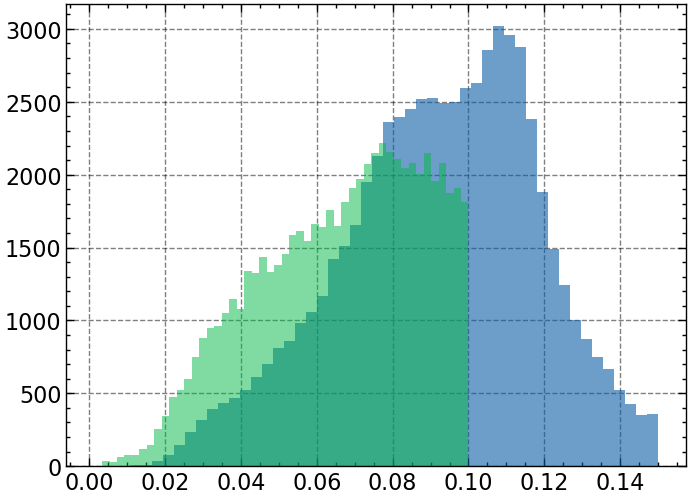

In [ ]:
plt.hist(unmatched_rows['Z_PHOT_MEDIAN'].data,bins=50,alpha=0.6)
plt.hist(unmatched_rows['Z_PHOT_L95'].data,bins=50,alpha=0.5)


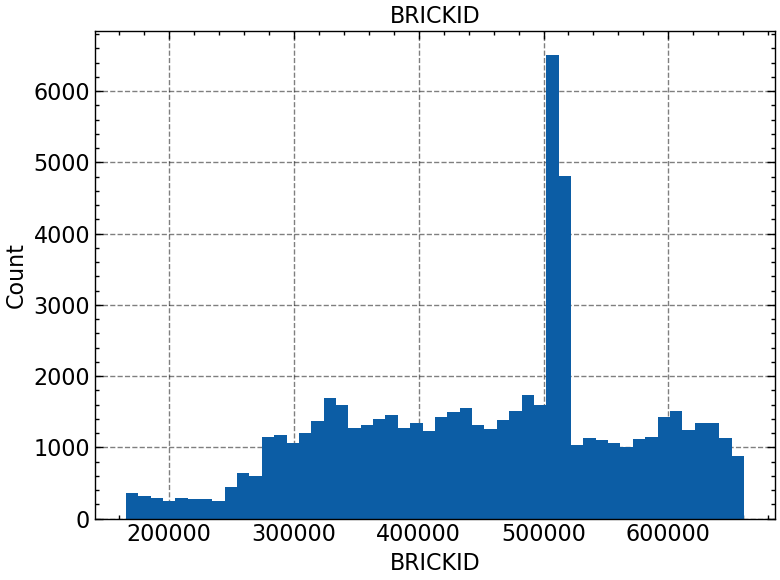

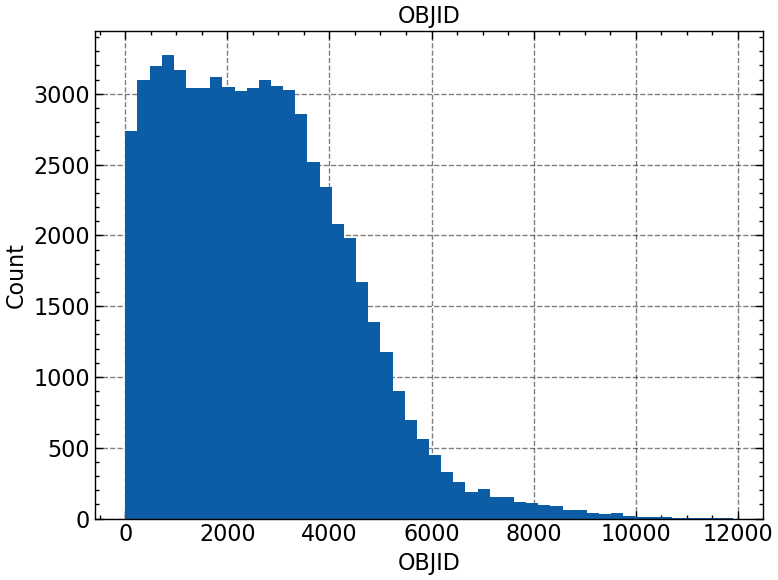

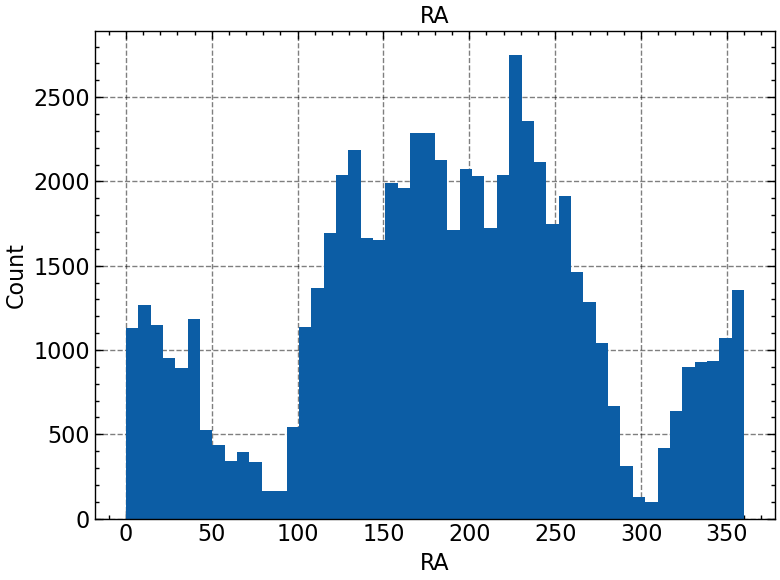

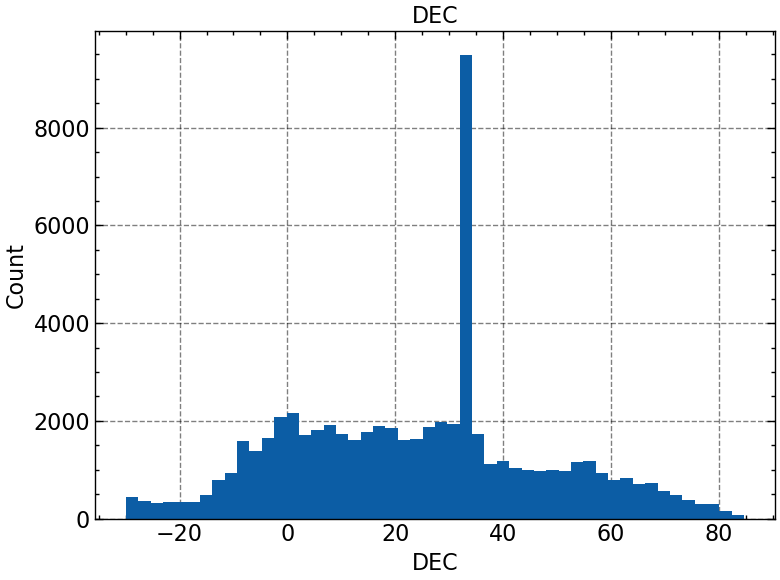

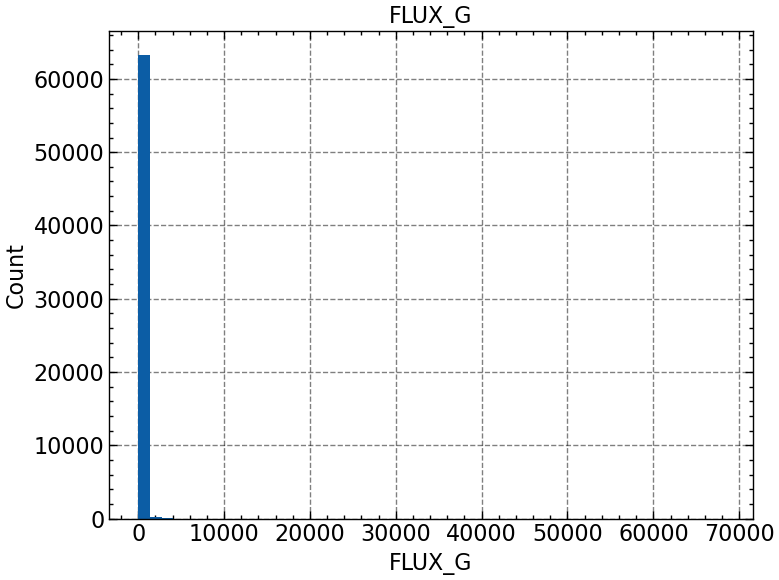

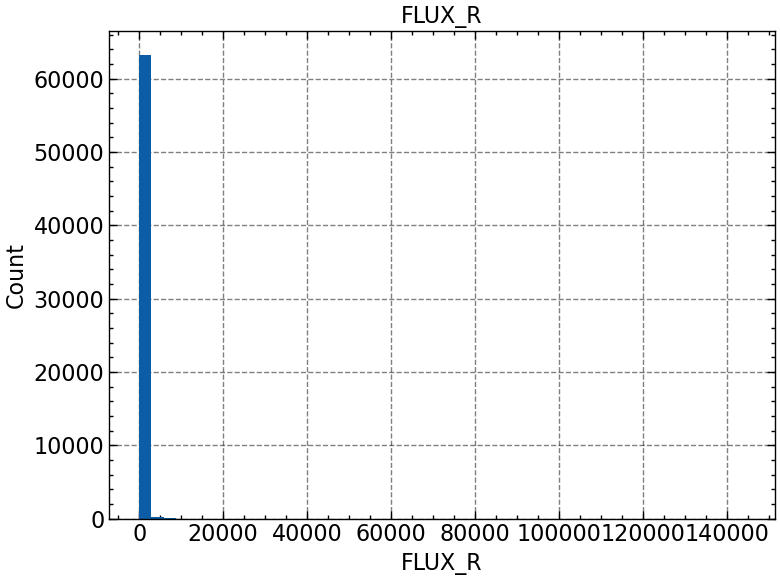

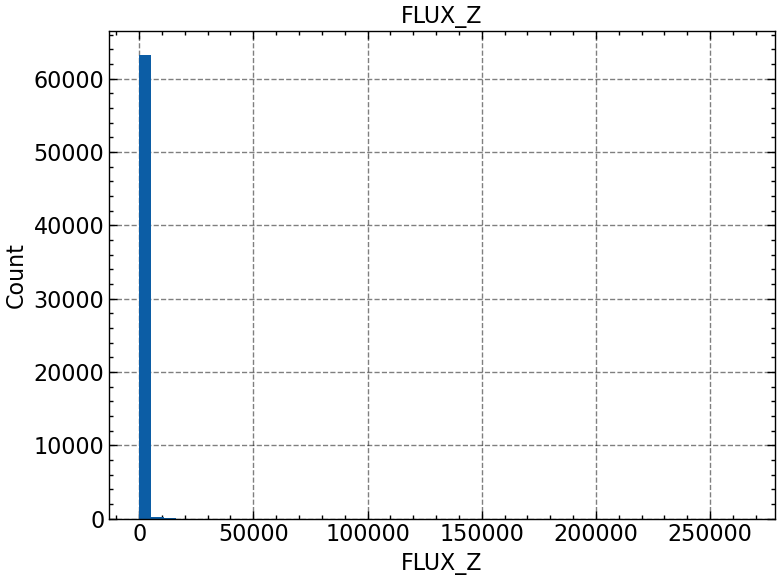

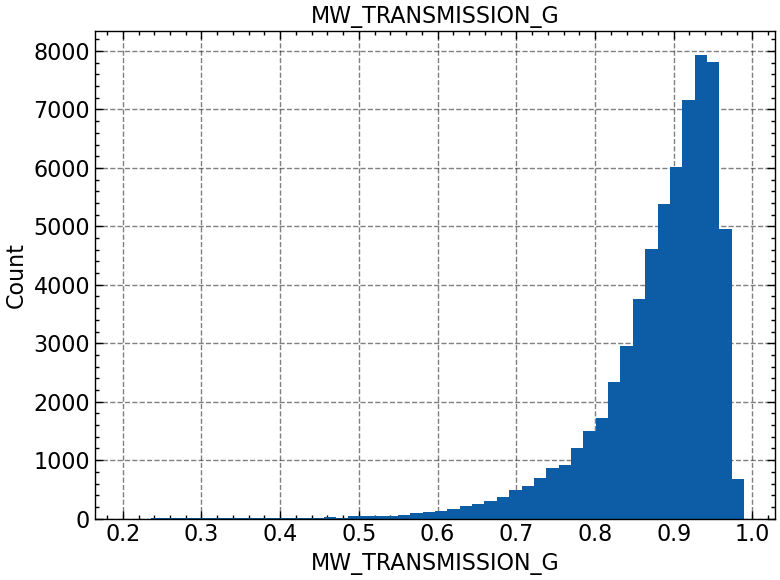

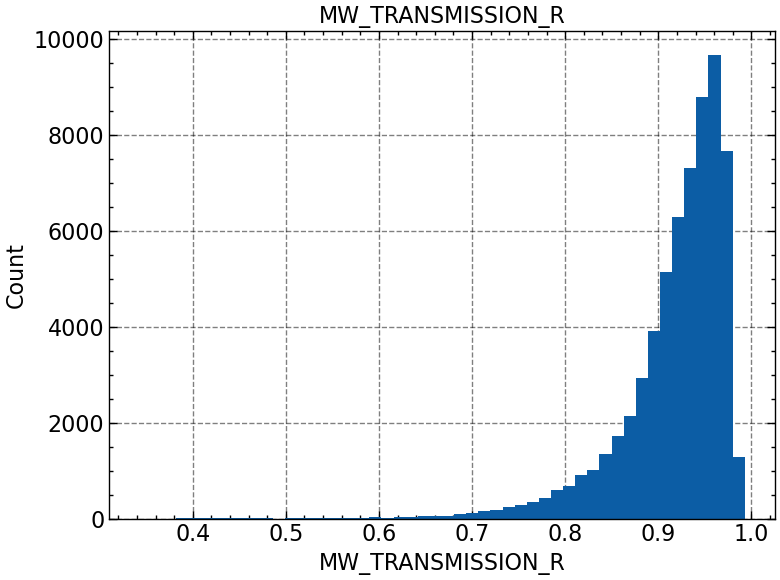

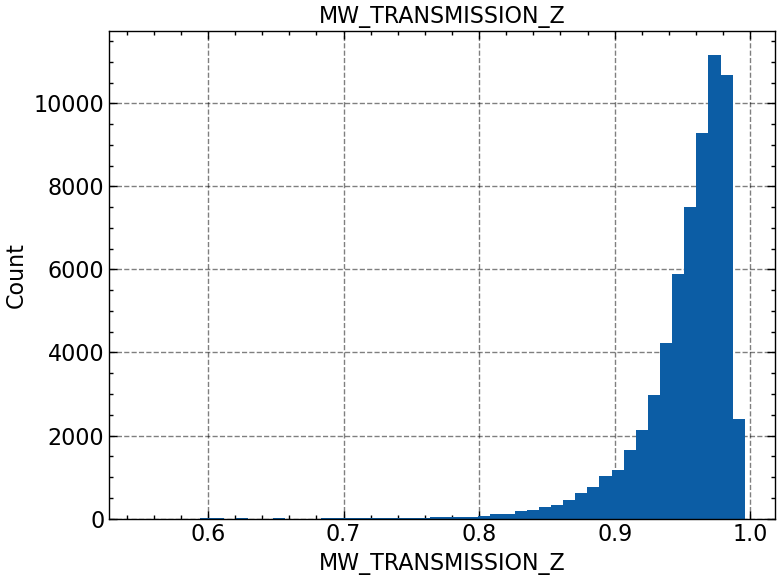

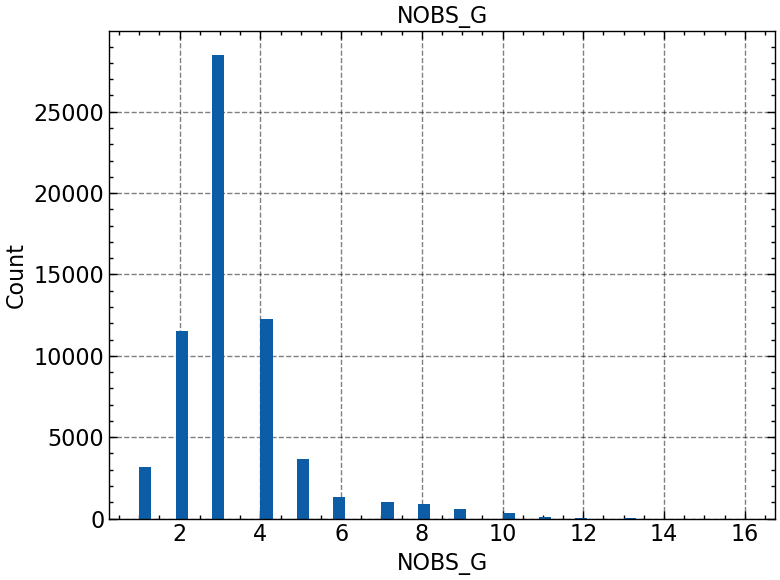

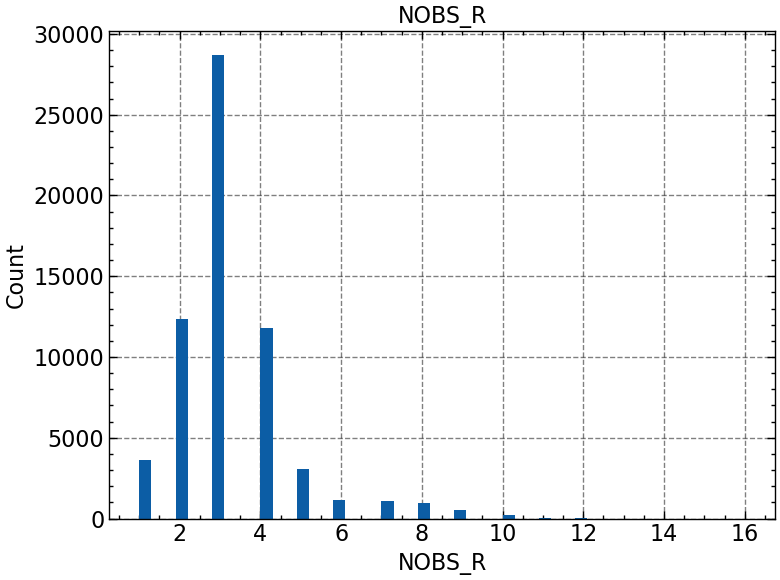

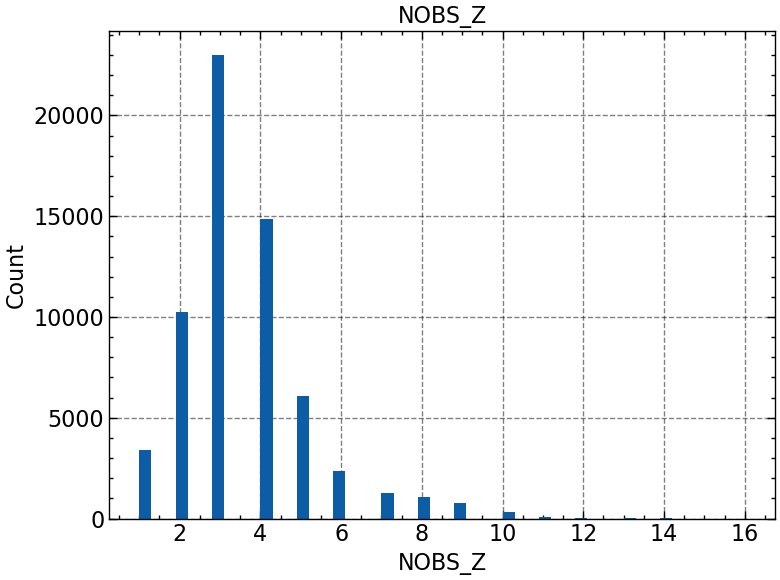

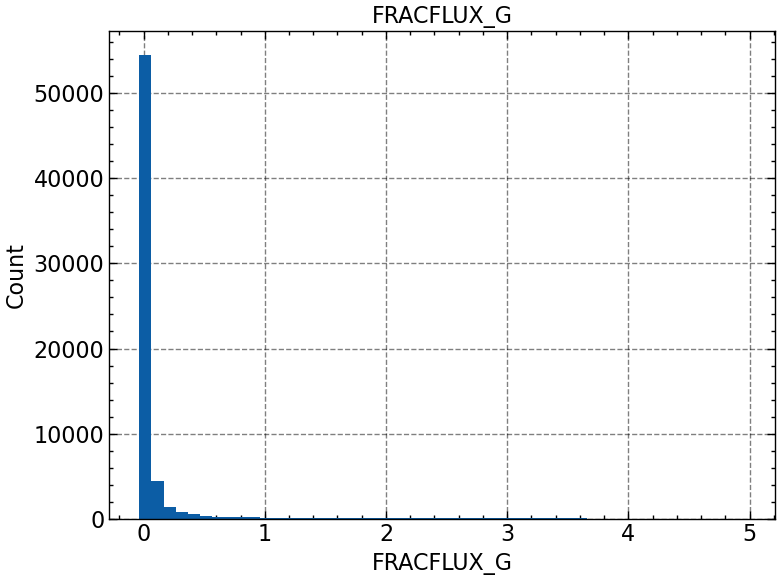

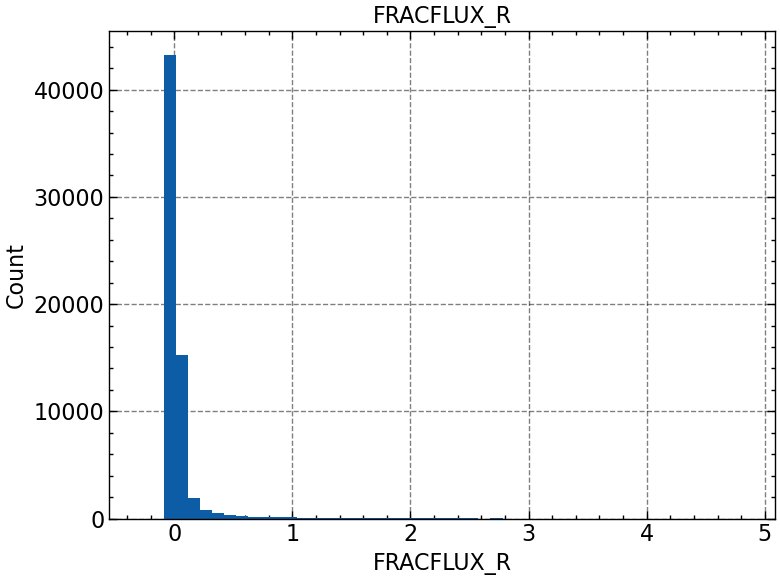

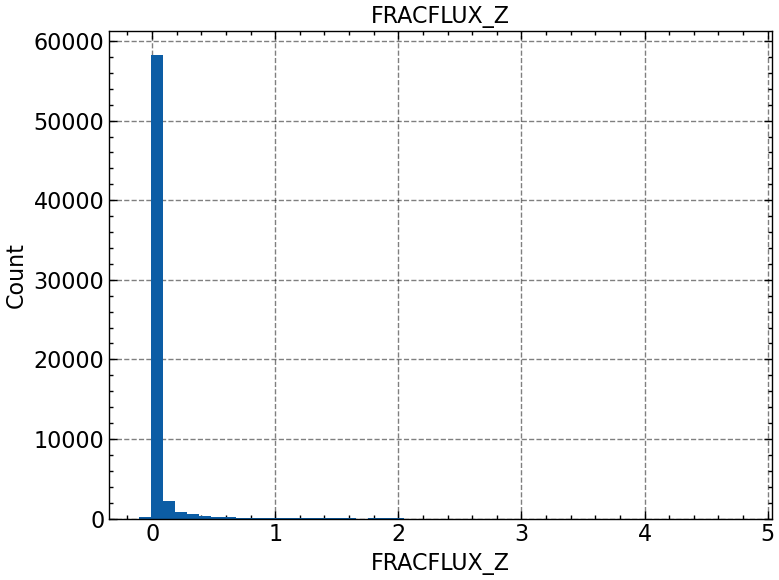

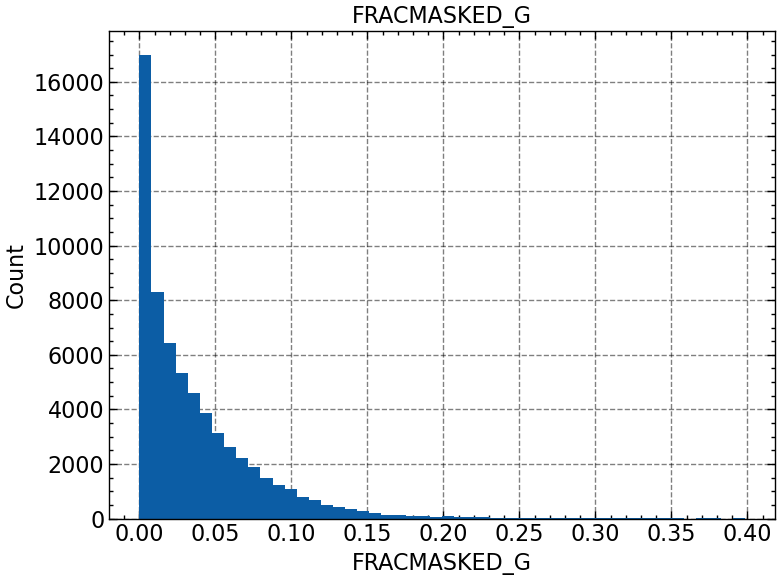

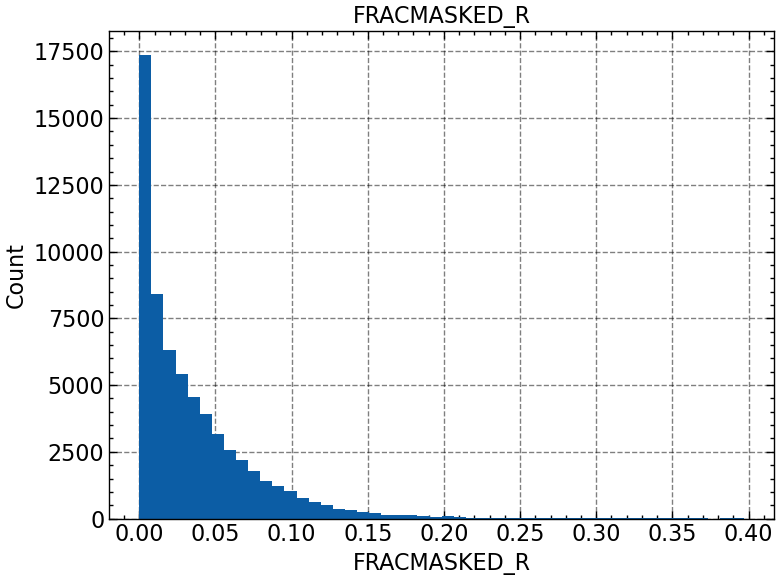

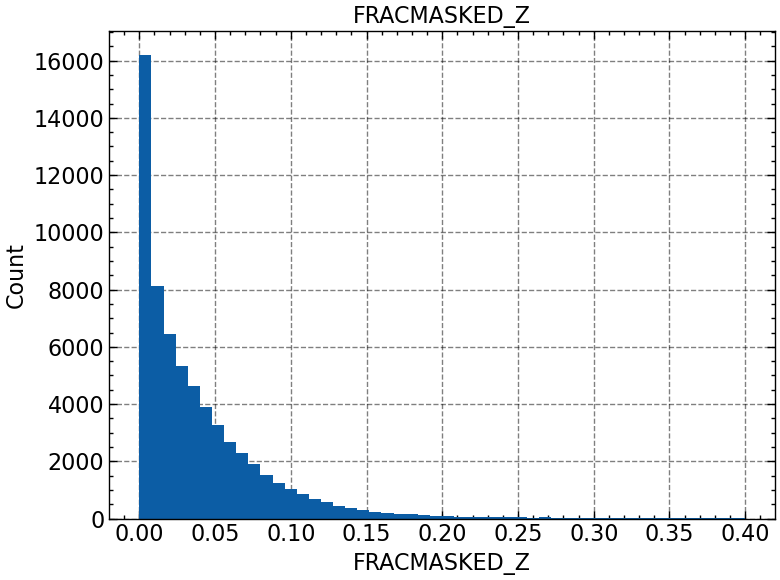

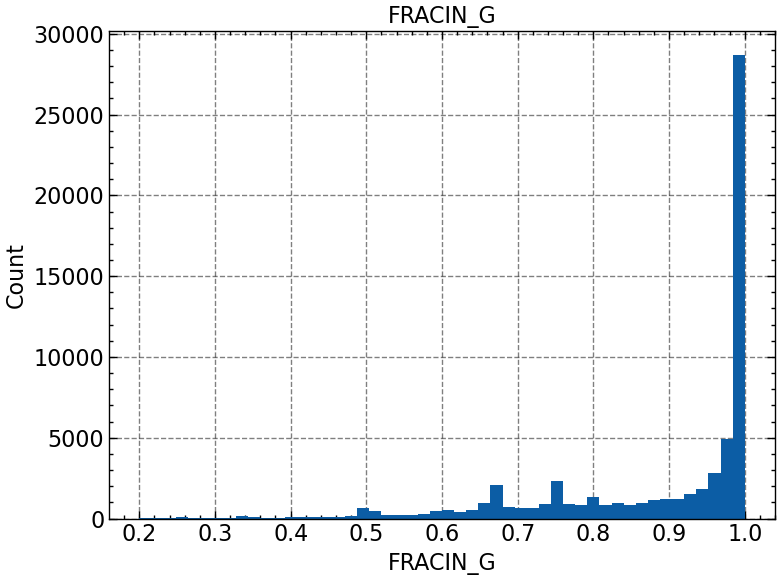

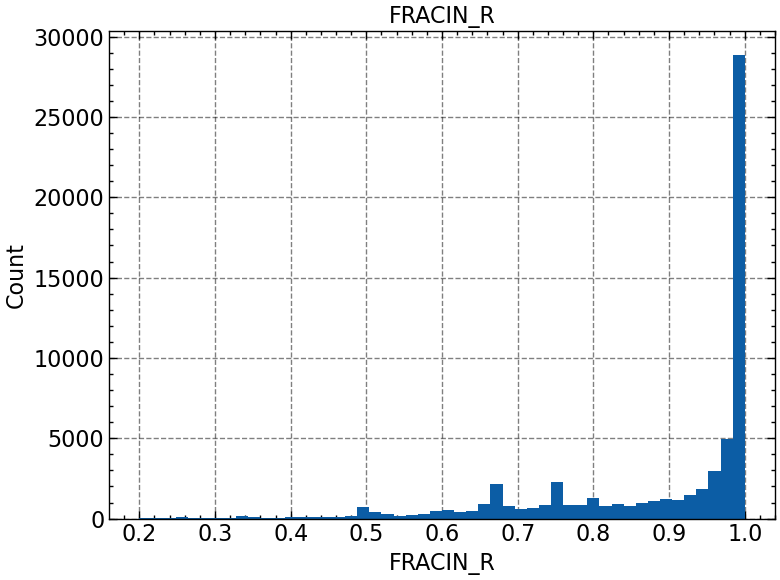

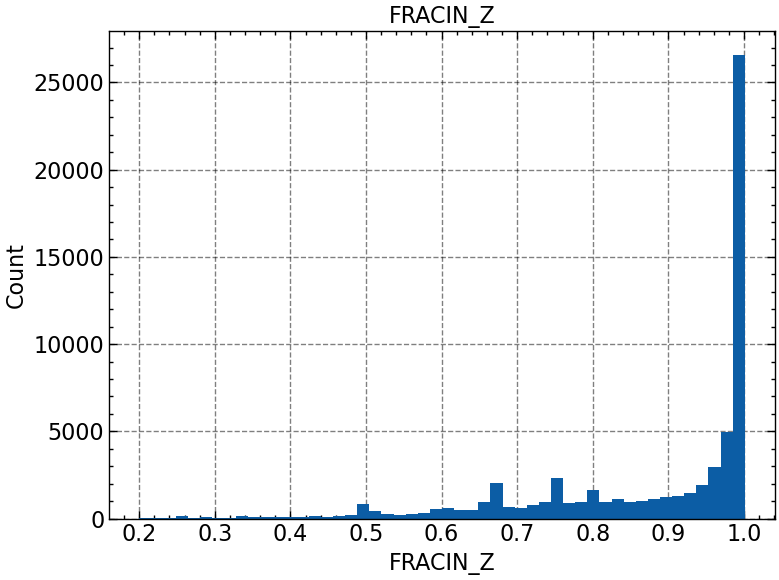

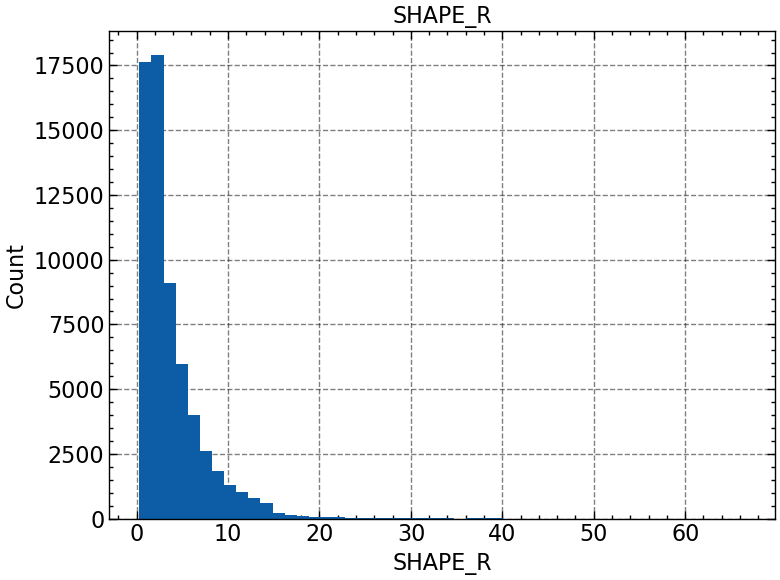

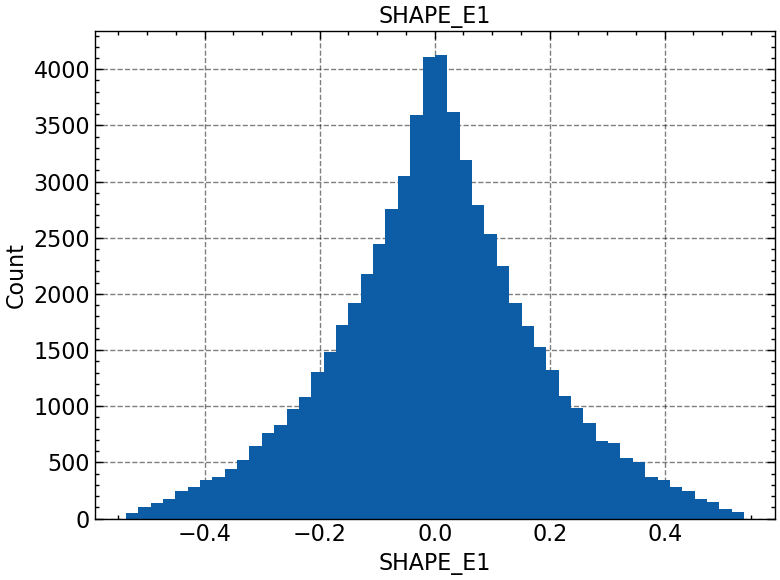

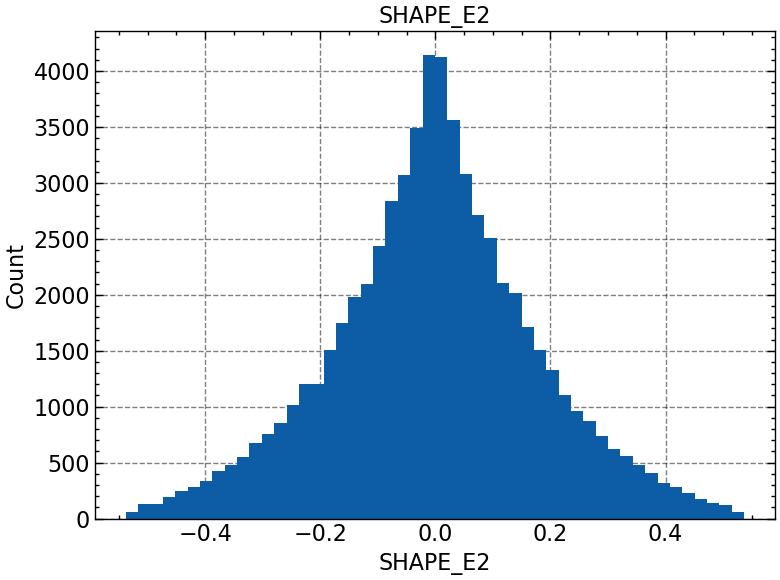

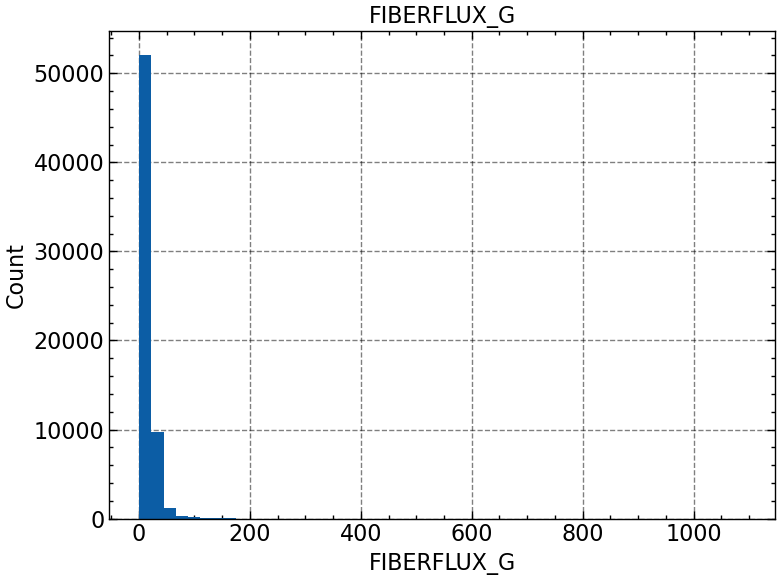

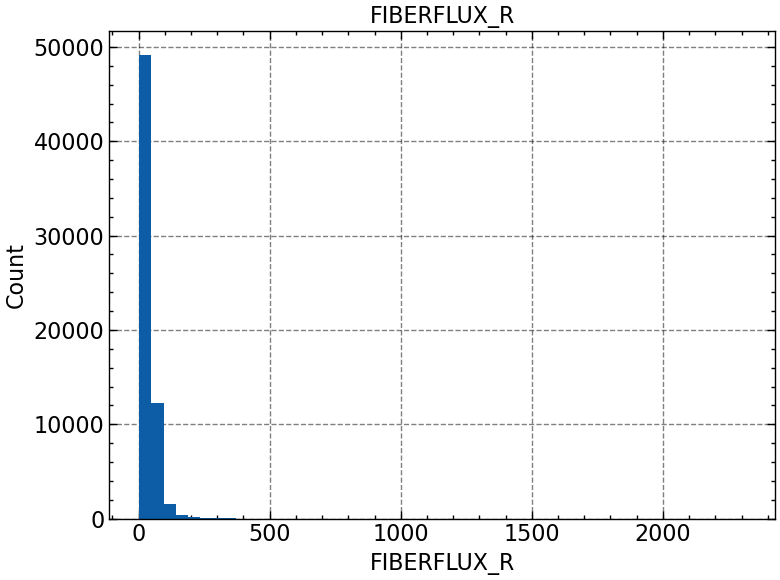

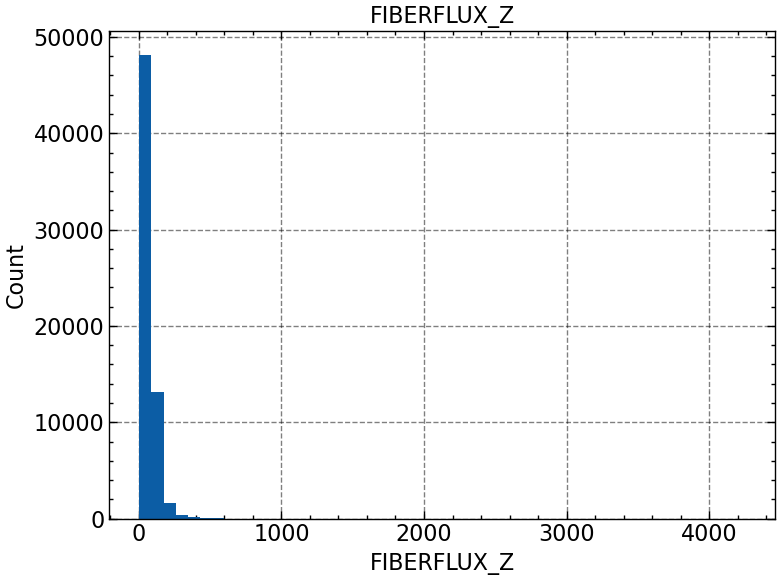

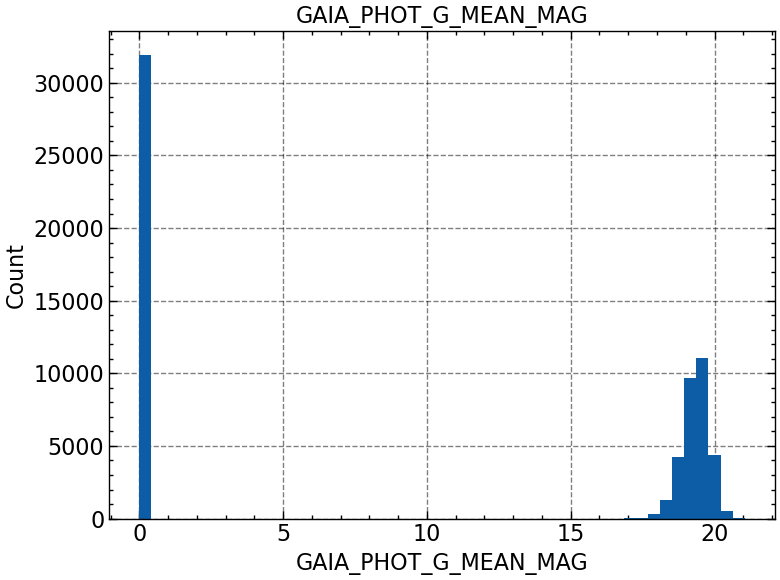

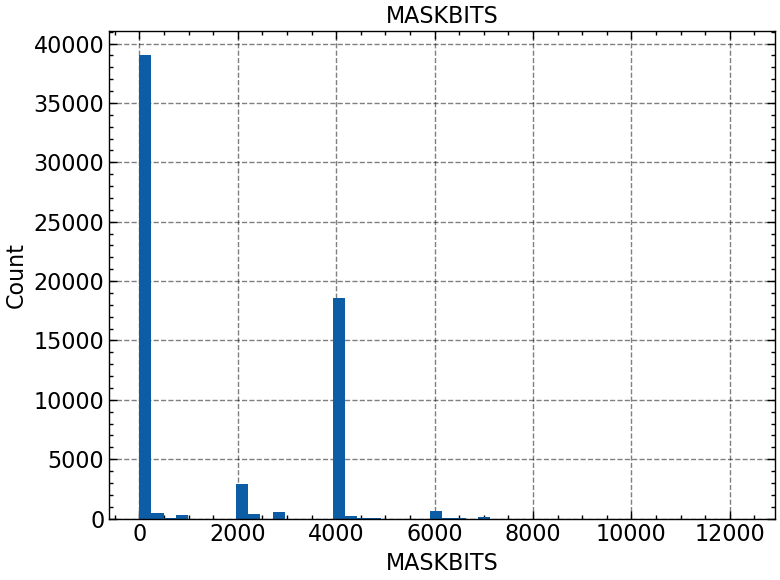

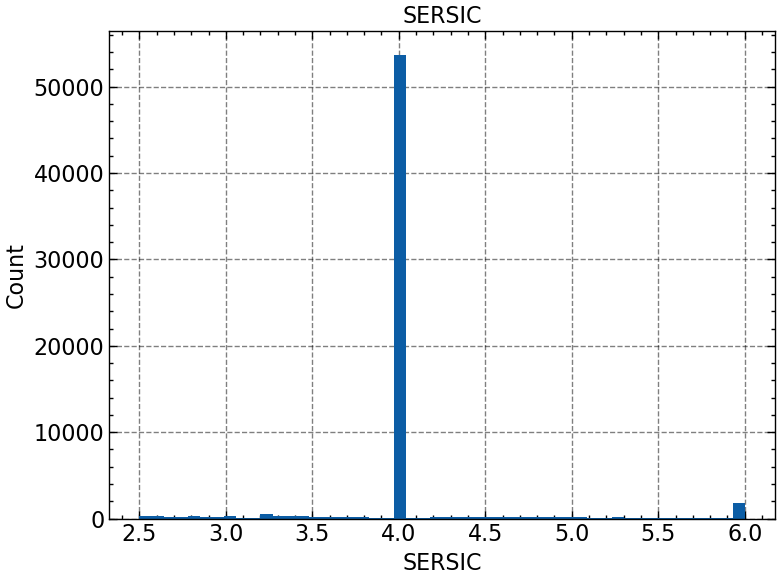

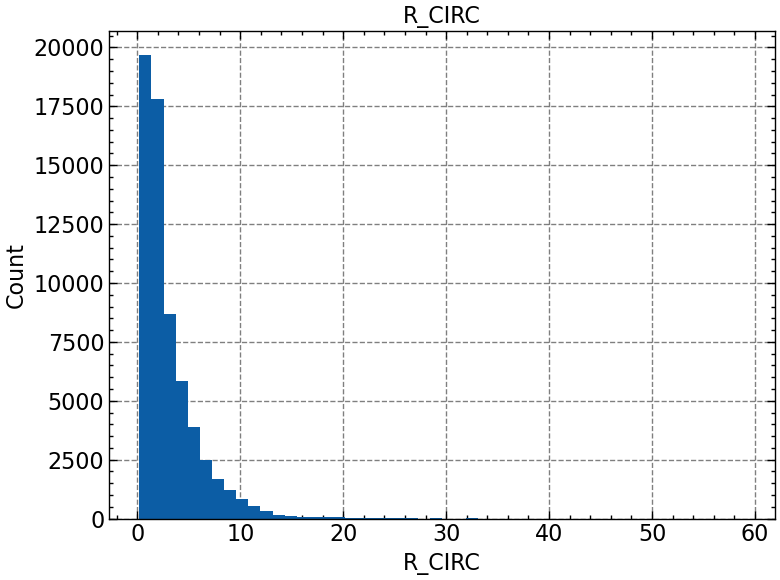

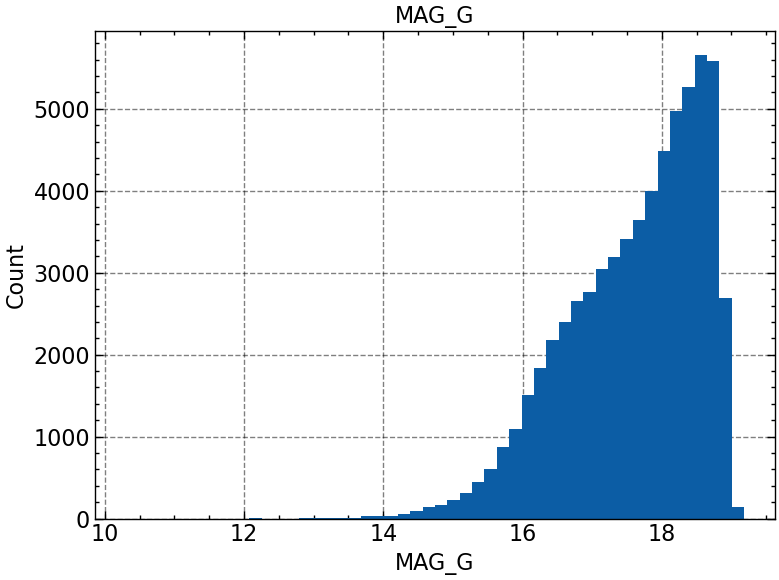

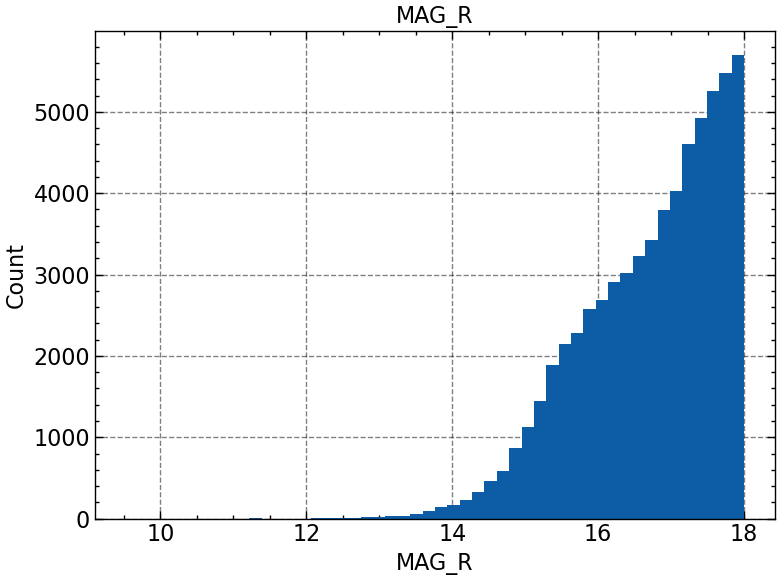

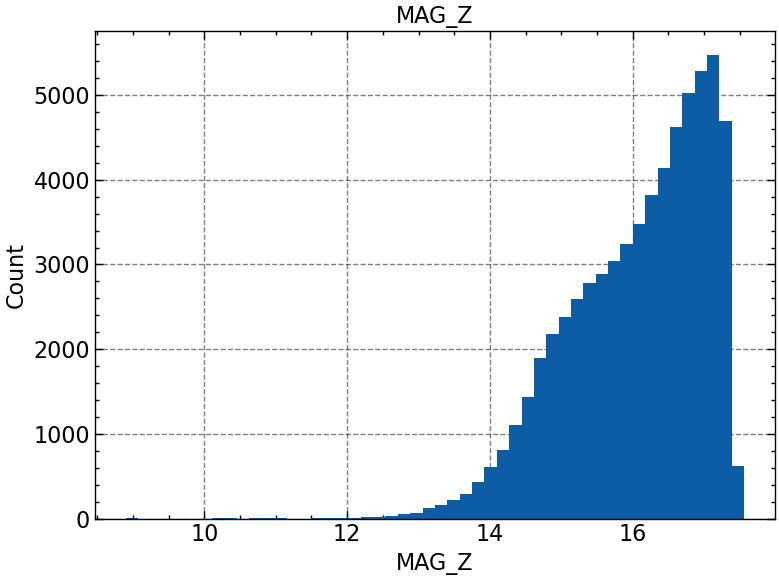

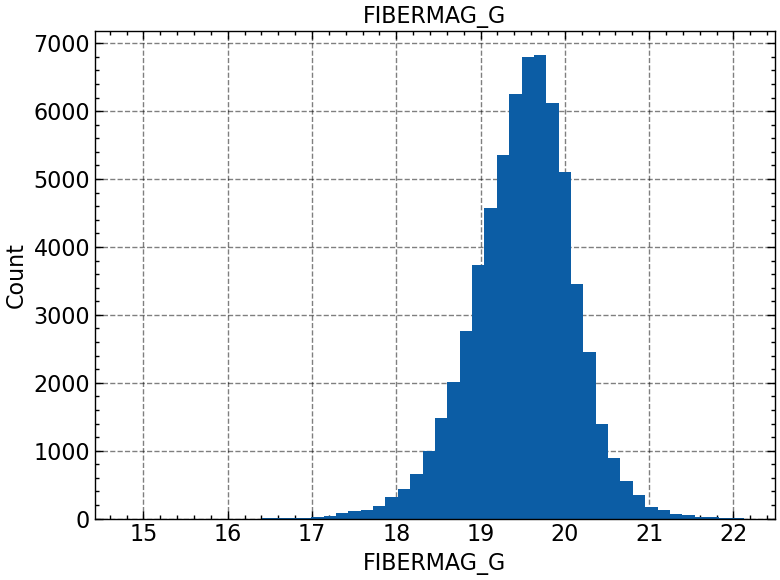

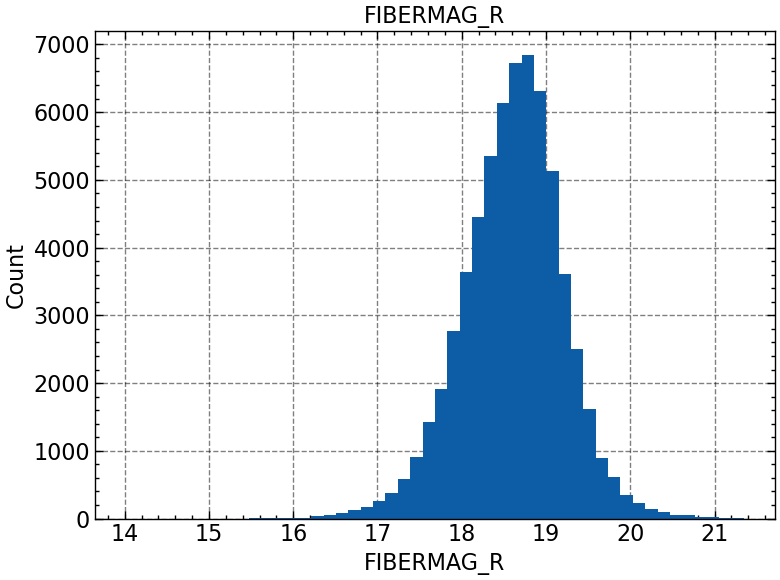

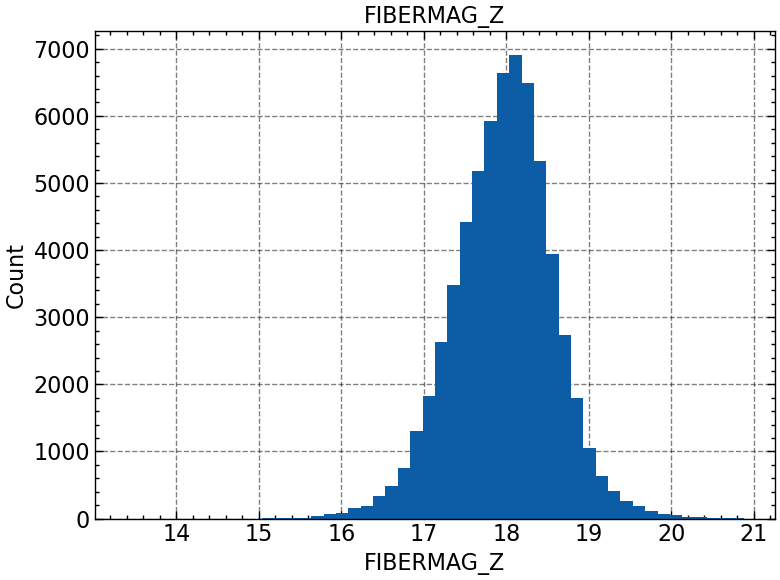

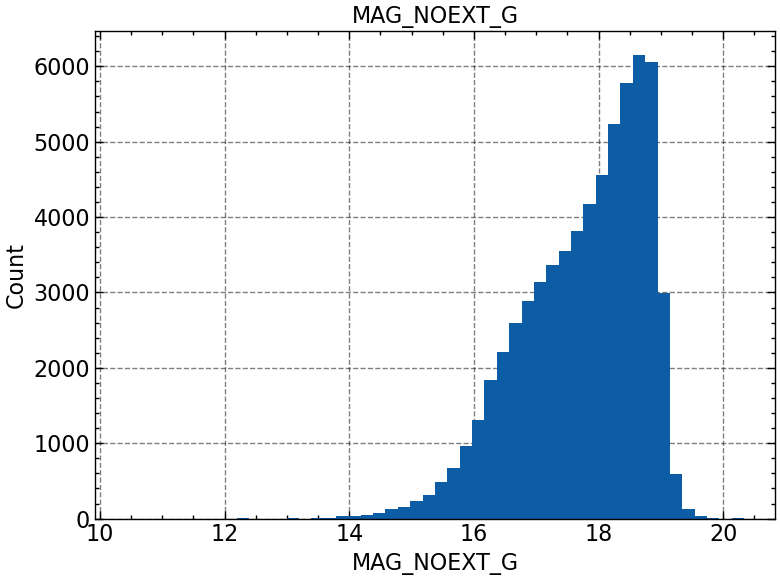

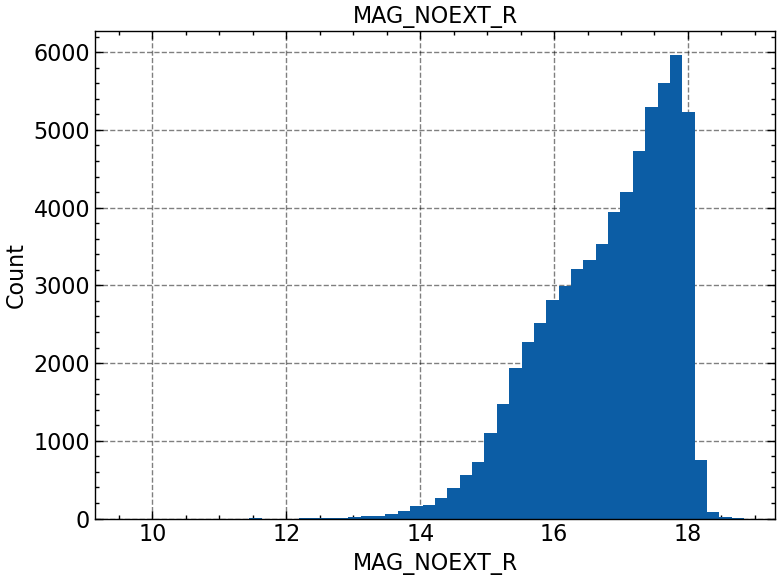

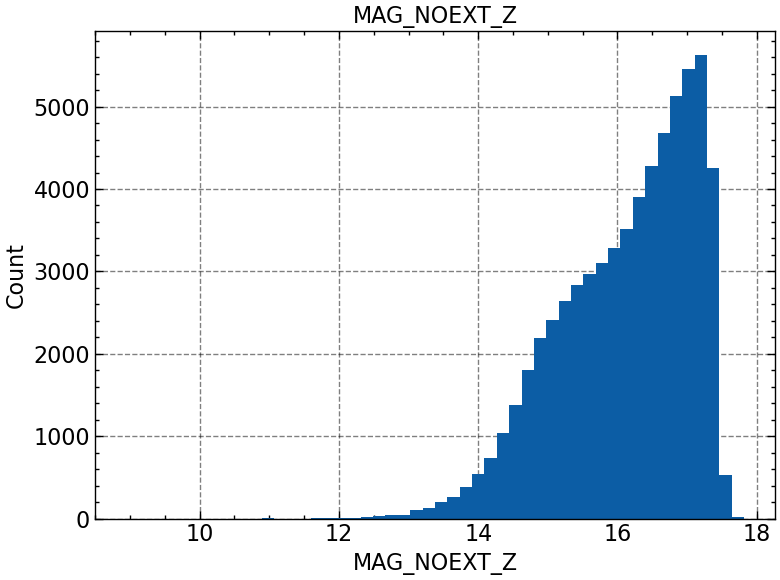

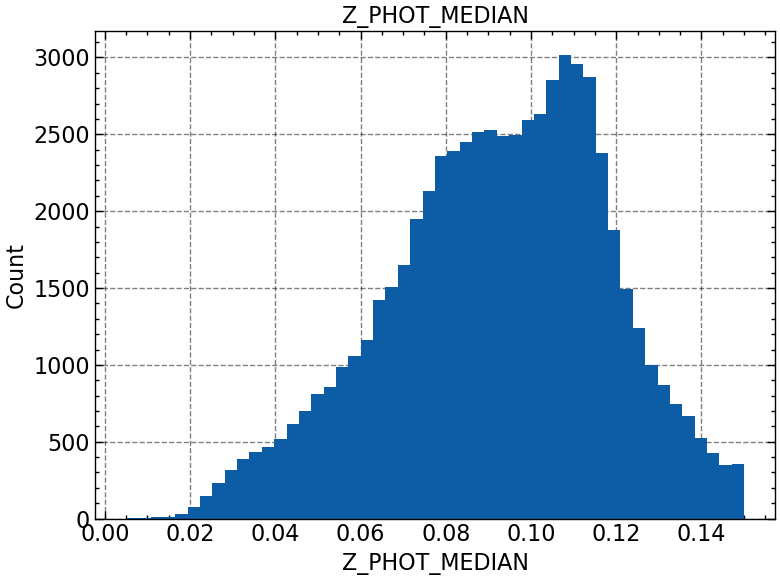

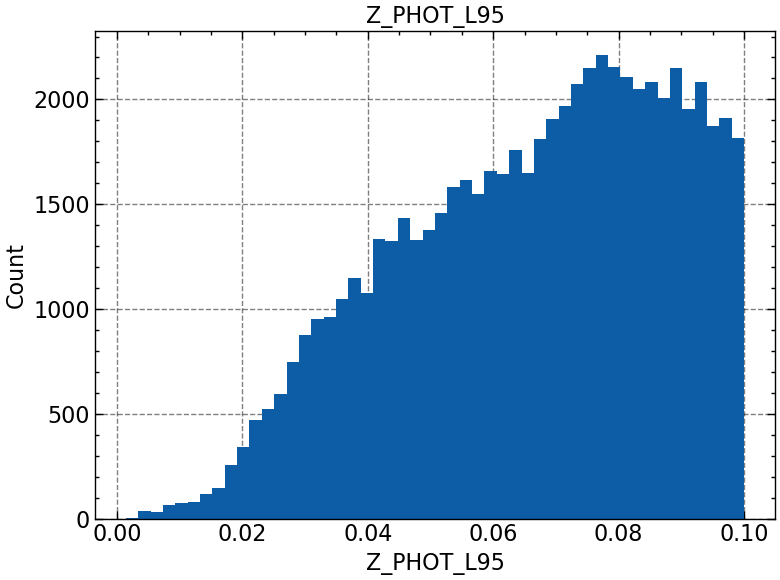

In [ ]:
for column in unmatched_rows.columns:
    if np.issubdtype(unmatched_rows[column].dtype, np.number):
        plt.figure(figsize=(8, 6))
        plt.hist(unmatched_rows[column], bins=50)
        plt.title(f"{column}")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [25]:
import pandas as pd

In [6]:
df=pd.read_parquet('/user/animesh.sah/DESI_PECVEL/summary_cuts_south_v3_selection_code.parquet')

In [7]:
df['masked']

0         508
1        1717
2        7905
3      721405
4       82686
        ...  
450      3406
451      3035
452      3826
453    229556
454         1
Name: masked, Length: 455, dtype: int64

In [9]:
df.columns

Index(['name', 'total', 'masked', 'cuts', 'cumulative', 'final_table_length'], dtype='object')

In [11]:
sum(df['final_table_length'])-339407

86274

In [26]:
import pickle

In [27]:
with open("south_dict_v1.pkl", "rb") as f:
    merged = pickle.load(f)

In [28]:
south_new=merged[BGS_mask(merged)]

In [32]:
table_south_cut

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
328953,0063m002,590,SER,6.26362716189572,-0.1499482513838886,300.60703,652.61847,1180.8732,0.92847264,0.9512371,0.9724242,8,8,6,0.9471645,0.024401104,0.28148246,0.041056655,0.040694147,0.040398907,0.7978986,0.8893565,0.74753237,5.2347727,0.052645862,-0.16757756,27.003803,58.625313,106.07891,0.0,4096,3.3263562,4.383424,16.224424,15.409073,14.789131,18.84086,18.025509,17.405567,16.305002,15.463352,14.819491,0.06403214,0.044679843
328953,0063m002,6221,SER,6.41306861705127,-0.28716797343408407,145.07045,338.60498,627.2054,0.93664,0.95686555,0.97563845,9,10,8,0.006443584,0.004117686,0.0031034444,0.026262075,0.018250097,0.01589204,0.9009277,0.9100984,0.9893653,3.557781,0.044396967,0.053775623,20.023476,46.73625,86.57058,0.0,4096,4.135151,3.3177574,17.024984,16.127893,15.479698,19.175083,18.277992,17.629795,17.096052,16.175766,15.506475,0.08380653,0.06967464
328953,0063m002,6645,SER,6.422688275321659,-0.37481648471724915,175.64865,367.90442,632.70404,0.938803,0.9583535,0.9764868,8,9,7,0.0010322763,0.0057133944,0.0018554571,0.011669909,0.010976144,0.010810562,0.8149766,0.6898645,0.775109,3.7546372,0.062972225,0.14860792,26.807844,56.1503,96.56454,0.0,4096,4.621181,3.1904702,16.819824,16.039476,15.471165,18.86078,18.080435,17.512121,16.888388,16.085663,15.496998,0.032462,0.024623377
330393,0063p000,7270,SER,6.436389809400173,-0.00955802621282362,314.02246,711.0175,1380.097,0.9275413,0.95059425,0.97205657,7,7,7,0.006167093,0.0032024574,0.0012248257,0.014775223,0.0072217947,0.09015836,0.60175765,0.59648013,0.8522192,3.8330562,0.00061665237,-0.24728347,38.568882,87.32863,169.50635,0.0,4096,2.9695756,2.9776797,16.17593,15.315287,14.619454,18.45274,17.592096,16.896263,16.257599,15.370299,14.650226,0.04460466,0.009056895
314552,0061m027,3772,SER,6.102470790280238,-2.6691970876641204,281.30212,639.7425,1178.891,0.9074451,0.93667114,0.9640669,8,7,7,0.0016365226,0.00066971977,0.0015138617,0.048754565,0.053993665,0.052033685,0.72186935,0.6413724,0.64553714,3.9950166,-0.16194214,0.06696437,46.017582,104.65404,192.85213,0.0,4096,5.4563866,3.3467135,16.271618,15.413955,14.781584,18.237242,17.379578,16.747208,16.377068,15.484987,14.821316,0.058474883,0.04874303
314552,0061m027,5305,SER,6.138643537472591,-2.8243411845971513,105.191895,242.40292,441.8875,0.9123736,0.94009495,0.96603644,6,8,5,8.167328e-05,2.1784033e-05,4.291893e-05,0.002474643,0.0054171495,0.002464217,0.70824885,0.839193,0.600995,2.6961966,-0.35977945,-0.26226214,20.386866,46.979244,85.64064,19.023493,0,2.6997793,1.6704899,17.345476,16.471584,15.849204,19.127056,18.253164,17.630783,17.445044,16.538654,15.886721,0.06834267,0.054366756
314552,0061m027,8631,SER,6.228928493043271,-2.748168582748646,57.000294,131.94614,248.53636,0.9141382,0.94131935,0.96674,9,8,8,0.020470582,0.010708456,0.009086735,0.011170484,0.015601107,0.016095122,0.9041829,0.7995394,0.8409605,2.2512336,0.005970428,0.10867902,13.89505,32.16471,60.58609,19.24061,0,6.0,2.018193,18.012836,17.13335,16.4748,19.54538,18.665894,18.007341,18.110308,17.199009,16.511524,0.08575495,0.061975703
314552,0061m027,8875,DEV,6.2364056224512465,-2.6820972282966293,242.55896,578.9339,1106.3315,0.9165458,0.94298863,0.9676986,10,10,10,0.81940395,0.40417257,0.08592578

In [31]:
south_new=south_new[south_new['DEC']>-30]
south_new

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
328953,0063m002,590,SER,6.26362716189572,-0.1499482513838886,300.60703,652.61847,1180.8732,0.92847264,0.9512371,0.9724242,8,8,6,0.9471645,0.024401104,0.28148246,0.041056655,0.040694147,0.040398907,0.7978986,0.8893565,0.74753237,5.2347727,0.052645862,-0.16757756,27.003803,58.625313,106.07891,0.0,4096,3.3263562,4.383424,16.224424,15.409073,14.789131,18.84086,18.025509,17.405567,16.305002,15.463352,14.819491,0.06403214,0.044679843
328953,0063m002,6221,SER,6.41306861705127,-0.28716797343408407,145.07045,338.60498,627.2054,0.93664,0.95686555,0.97563845,9,10,8,0.006443584,0.004117686,0.0031034444,0.026262075,0.018250097,0.01589204,0.9009277,0.9100984,0.9893653,3.557781,0.044396967,0.053775623,20.023476,46.73625,86.57058,0.0,4096,4.135151,3.3177574,17.024984,16.127893,15.479698,19.175083,18.277992,17.629795,17.096052,16.175766,15.506475,0.08380653,0.06967464
328953,0063m002,6645,SER,6.422688275321659,-0.37481648471724915,175.64865,367.90442,632.70404,0.938803,0.9583535,0.9764868,8,9,7,0.0010322763,0.0057133944,0.0018554571,0.011669909,0.010976144,0.010810562,0.8149766,0.6898645,0.775109,3.7546372,0.062972225,0.14860792,26.807844,56.1503,96.56454,0.0,4096,4.621181,3.1904702,16.819824,16.039476,15.471165,18.86078,18.080435,17.512121,16.888388,16.085663,15.496998,0.032462,0.024623377
330393,0063p000,7270,SER,6.436389809400173,-0.00955802621282362,314.02246,711.0175,1380.097,0.9275413,0.95059425,0.97205657,7,7,7,0.006167093,0.0032024574,0.0012248257,0.014775223,0.0072217947,0.09015836,0.60175765,0.59648013,0.8522192,3.8330562,0.00061665237,-0.24728347,38.568882,87.32863,169.50635,0.0,4096,2.9695756,2.9776797,16.17593,15.315287,14.619454,18.45274,17.592096,16.896263,16.257599,15.370299,14.650226,0.04460466,0.009056895
314552,0061m027,3772,SER,6.102470790280238,-2.6691970876641204,281.30212,639.7425,1178.891,0.9074451,0.93667114,0.9640669,8,7,7,0.0016365226,0.00066971977,0.0015138617,0.048754565,0.053993665,0.052033685,0.72186935,0.6413724,0.64553714,3.9950166,-0.16194214,0.06696437,46.017582,104.65404,192.85213,0.0,4096,5.4563866,3.3467135,16.271618,15.413955,14.781584,18.237242,17.379578,16.747208,16.377068,15.484987,14.821316,0.058474883,0.04874303
314552,0061m027,5305,SER,6.138643537472591,-2.8243411845971513,105.191895,242.40292,441.8875,0.9123736,0.94009495,0.96603644,6,8,5,8.167328e-05,2.1784033e-05,4.291893e-05,0.002474643,0.0054171495,0.002464217,0.70824885,0.839193,0.600995,2.6961966,-0.35977945,-0.26226214,20.386866,46.979244,85.64064,19.023493,0,2.6997793,1.6704899,17.345476,16.471584,15.849204,19.127056,18.253164,17.630783,17.445044,16.538654,15.886721,0.06834267,0.054366756
314552,0061m027,8631,SER,6.228928493043271,-2.748168582748646,57.000294,131.94614,248.53636,0.9141382,0.94131935,0.96674,9,8,8,0.020470582,0.010708456,0.009086735,0.011170484,0.015601107,0.016095122,0.9041829,0.7995394,0.8409605,2.2512336,0.005970428,0.10867902,13.89505,32.16471,60.58609,19.24061,0,6.0,2.018193,18.012836,17.13335,16.4748,19.54538,18.665894,18.007341,18.110308,17.199009,16.511524,0.08575495,0.061975703
314552,0061m027,8875,DEV,6.2364056224512465,-2.6820972282966293,242.55896,578.9339,1106.3315,0.9165458,0.94298863,0.9676986,10,10,10,0.81940395,0.40417257,0.08592578

In [33]:
table = vstack([table_north_cut, south_new])
table = unique(table, keys=['BRICKID', 'OBJID','BRICKNAME'])
table 

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
165253,0027m300,965,SER,2.62843215831155,-29.91925624962128,29.589272,69.85892,120.78643,0.96353453,0.97528774,0.9861009,4,3,3,0.008256373,0.0038269241,0.0022503377,0.1046411,0.007468015,0.008222433,0.9908769,0.9793203,0.952676,1.439051,0.056706924,0.4707824,10.633193,25.104483,43.40578,19.594368,0,5.365548,0.8594418,18.781832,17.862278,17.279758,19.89301,18.973454,18.390934,18.822165,17.889446,17.294954,0.11925707,0.07404
165253,0027m300,8018,SER,2.863540922350348,-29.985583424278076,97.60628,213.71559,357.0383,0.9634142,0.97520566,0.98605454,5,4,4,0.0039558485,0.0015543617,0.001746305,0.015935633,0.015104101,0.014372644,0.71346325,0.7980461,0.79839915,2.8665063,0.006381261,0.20037729,18.40419,40.297226,67.321495,19.03229,0,4.3995013,2.3393254,17.485838,16.64815,16.102964,19.297241,18.459553,17.914368,17.526306,16.67541,16.118214,0.08216938,0.05233359
165254,0030m300,2729,SER,2.959861190581655,-29.976833409107144,133.6931,302.06693,545.4084,0.9645446,0.9759763,0.9864903,6,5,5,0.009309506,0.009026461,0.008460421,0.035788488,0.054935064,0.035521712,0.6832331,0.6349298,0.78917336,5.465792,0.13749963,-0.17273739,9.752995,22.035969,39.78788,0.0,4096,2.5810404,4.366806,17.145533,16.27334,15.643427,19.98796,19.115768,18.485855,17.184727,16.299742,15.6581955,0.10260826,0.079693824
165255,0033m300,2437,SER,3.242204419597018,-29.965335681021642,89.15787,202.9126,363.35596,0.96199393,0.974237,0.9855066,10,8,8,0.007147767,0.0075664036,0.007917962,0.010226642,0.0061172945,0.0051263277,0.9090077,0.8885625,0.88719994,2.9307039,0.36358386,0.14786936,19.57327,44.546417,79.76935,0.0,4096,4.886093,1.9357351,17.582531,16.703388,16.083317,19.228771,18.349628,17.729559,17.624601,16.731728,16.099169,0.07002529,0.041350946
165257,0038m300,6111,SER,3.919789628016901,-29.961178984068038,74.51839,149.5096,240.37823,0.9498003,0.9659014,0.98078114,11,9,9,0.014173677,0.010118711,0.0141074285,0.077337496,0.07685828,0.084938005,0.8987434,0.97904754,0.8051987,5.2499204,0.35237825,0.075496554,7.746992,15.543139,24.989918,0.0,0,3.20539,3.5998638,17.763422,17.02566,16.526691,20.221249,19.483484,18.984518,17.819342,17.063328,16.547762,0.093006395,0.044483088
165258,0041m300,690,SER,4.048538258520457,-29.972884287167602,358.9719,788.084,1381.0511,0.9535388,0.9684607,0.9822339,14,11,9,0.00044445426,0.00031957513,0.00036906582,0.05397016,0.05349998,0.058807805,0.8793855,0.8675587,0.8081867,9.583365,-0.03486811,0.26829654,22.80636,50.068897,87.74155,0.0,4096,4.0432916,7.261371,16.060696,15.223773,14.6300125,19.053205,18.216286,17.622524,16.112349,15.258569,14.649475,0.070030585,0.044504732
165266,0064m300,1729,SER,6.392469240455067,-29.907983020577632,68.03752,174.73416,349.57288,0.95465136,0.9692218,0.9826656,9,8,9,0.0052018464,0.0028862131,0.0010956088,0.002436002,0.0023598466,0.002097837,0.9910156,0.89358157,0.99360394,2.7591364,0.062528394,-0.43060791,12.846766,32.9931,66.00594,0.0,0,2.7234747,1.7310315,17.86774,16.860113,16.12217,19.677628,18.67,17.932056,17.918129,16.894054,16.141155,0.13275577,0.0908464
165268,0070m300,7351,SER,7.135888755094763,-29.92366798003355,57.760338,124.72824,220.21753,0.95099914,0.9667224,0.98124737,7,9,7,0.017944174,0.005865567,0.0020204452,0.075983904,0.07

In [42]:

common = join(
    table,
    final_unique_rows,
    keys=[  'BRICKID','OBJID','BRICKNAME'],
    join_type='inner')

In [43]:
final_unique_rows

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,FLUX_G,FLUX_R,FLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN,Z_PHOT_L95,bba
int32,bytes8,int32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32,float32
165253,0027m300,965,SER,2.62843215831155,-29.91925624962128,29.589272,69.85892,120.78643,0.96353453,0.97528774,0.9861009,4,3,3,0.008256373,0.0038269241,0.0022503377,0.1046411,0.007468015,0.008222433,0.9908769,0.9793203,0.952676,1.439051,0.056706924,0.4707824,10.633193,25.104483,43.40578,19.594368,0,5.365548,0.8594418,18.781832,17.862278,17.279758,19.89301,18.973454,18.390934,18.822165,17.889446,17.294954,2.62843215831,-29.91925624962,2015.5,false,FPT,1,1,2841831167492096,0.11925707,0.07404,0.3566815
165253,0027m300,8018,SER,2.863540922350348,-29.985583424278076,97.60628,213.71559,357.0383,0.9634142,0.97520566,0.98605454,5,4,4,0.0039558485,0.0015543617,0.001746305,0.015935633,0.015104101,0.014372644,0.71346325,0.7980461,0.79839915,2.8665063,0.006381261,0.20037729,18.40419,40.297226,67.321495,19.03229,0,4.3995013,2.3393254,17.485838,16.64815,16.102964,19.297241,18.459553,17.914368,17.526306,16.67541,16.118214,2.86354092235,-29.98558342428,2015.5,false,FPT,1,1,2841831167492097,0.08216938,0.05233359,0.66600186
165254,0030m300,2729,SER,2.959861190581655,-29.976833409107144,133.6931,302.06693,545.4084,0.9645446,0.9759763,0.9864903,6,5,5,0.009309506,0.009026461,0.008460421,0.035788488,0.054935064,0.035521712,0.6832331,0.6349298,0.78917336,5.465792,0.13749963,-0.17273739,9.752995,22.035969,39.78788,0.0,4096,2.5810404,4.366806,17.145533,16.27334,15.643427,19.98796,19.115768,18.485855,17.184727,16.299742,15.6581955,2.95986119058,-29.97683340911,2015.5,false,FPT,1,1,2841831171686402,0.10260826,0.079693824,0.63829523
165255,0033m300,2437,SER,3.242204419597018,-29.965335681021642,89.15787,202.9126,363.35596,0.96199393,0.974237,0.9855066,10,8,8,0.007147767,0.0075664036,0.007917962,0.010226642,0.0061172945,0.0051263277,0.9090077,0.8885625,0.88719994,2.9307039,0.36358386,0.14786936,19.57327,44.546417,79.76935,0.0,4096,4.886093,1.9357351,17.582531,16.703388,16.083317,19.228771,18.349628,17.729559,17.624601,16.731728,16.099169,3.2422044196,-29.96533568102,2015.5,false,FPT,1,1,2841831175880704,0.07002529,0.041350946,0.43626264
165257,0038m300,6111,SER,3.919789628016901,-29.961178984068038,74.51839,149.5096,240.37823,0.9498003,0.9659014,0.98078114,11,9,9,0.014173677,0.010118711,0.0141074285,0.077337496,0.07685828,0.084938005,0.8987434,0.97904754,0.8051987,5.2499204,0.35237825,0.075496554,7.746992,15.543139,24.989918,0.0,0,3.20539,3.5998638,17.763422,17.02566,16.526691,20.221249,19.483484,18.984518,17.819342,17.063328,16.547762,3.91978962802,-29.96117898407,2015.5,false,FPT,1,1,2841831184269314,0.093006395,0.044483088,0.4701828
165258,0041m300,690,SER,4.048538258520457,-29.972884287167602,358.9719,788.084,1381.0511,0.9535388,0.9684607,0.9822339,14,11,9,0.00044445426,0.00031957513,0.00036906582,0.05397016,0.05349998,0.058807805,0.8793855,0.8675587,0.8081867,9.583365,-0.03486811,0.26829654,22.80636,50.068897,87.74155,0.0,4096,4.0432916,7.261371,16.060696,15.223773,14.6300125,19.053205,18.216286,17.622524,16.112349,15.258569,14.649475,4.04853825852,-29.97288428717,2015.5,false,FPT,1,1,2841831188463616,0.070030585,0.044504732,0.574117

In [44]:
common

BRICKID,BRICKNAME,OBJID,TYPE_1,RA_1,DEC_1,FLUX_G_1,FLUX_R_1,FLUX_Z_1,MW_TRANSMISSION_G_1,MW_TRANSMISSION_R_1,MW_TRANSMISSION_Z_1,NOBS_G_1,NOBS_R_1,NOBS_Z_1,FRACFLUX_G_1,FRACFLUX_R_1,FRACFLUX_Z_1,FRACMASKED_G_1,FRACMASKED_R_1,FRACMASKED_Z_1,FRACIN_G_1,FRACIN_R_1,FRACIN_Z_1,SHAPE_R_1,SHAPE_E1_1,SHAPE_E2_1,FIBERFLUX_G_1,FIBERFLUX_R_1,FIBERFLUX_Z_1,GAIA_PHOT_G_MEAN_MAG_1,MASKBITS_1,SERSIC_1,R_CIRC_1,MAG_G_1,MAG_R_1,MAG_Z_1,FIBERMAG_G_1,FIBERMAG_R_1,FIBERMAG_Z_1,MAG_NOEXT_G_1,MAG_NOEXT_R_1,MAG_NOEXT_Z_1,Z_PHOT_MEDIAN_1,Z_PHOT_L95_1,TYPE_2,RA_2,DEC_2,FLUX_G_2,FLUX_R_2,FLUX_Z_2,MW_TRANSMISSION_G_2,MW_TRANSMISSION_R_2,MW_TRANSMISSION_Z_2,NOBS_G_2,NOBS_R_2,NOBS_Z_2,FRACFLUX_G_2,FRACFLUX_R_2,FRACFLUX_Z_2,FRACMASKED_G_2,FRACMASKED_R_2,FRACMASKED_Z_2,FRACIN_G_2,FRACIN_R_2,FRACIN_Z_2,SHAPE_R_2,SHAPE_E1_2,SHAPE_E2_2,FIBERFLUX_G_2,FIBERFLUX_R_2,FIBERFLUX_Z_2,GAIA_PHOT_G_MEAN_MAG_2,MASKBITS_2,SERSIC_2,R_CIRC_2,MAG_G_2,MAG_R_2,MAG_Z_2,FIBERMAG_G_2,FIBERMAG_R_2,FIBERMAG_Z_2,MAG_NOEXT_G_2,MAG_NOEXT_R_2,MAG_NOEXT_Z_2,RA_ICRS,DE_ICRS,RefEpoch,Override,PVType,PVPriority,PointingID,TargetID,Z_PHOT_MEDIAN_2,Z_PHOT_L95_2,bba
int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes3,float64,float64,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,bytes5,bytes3,uint8,int16,int64,float32,float32,float32
165253,0027m300,965,SER,2.62843215831155,-29.91925624962128,29.589272,69.85892,120.78643,0.96353453,0.97528774,0.9861009,4,3,3,0.008256373,0.0038269241,0.0022503377,0.1046411,0.007468015,0.008222433,0.9908769,0.9793203,0.952676,1.439051,0.056706924,0.4707824,10.633193,25.104483,43.40578,19.594368,0,5.365548,0.8594418,18.781832,17.862278,17.279758,19.89301,18.973454,18.390934,18.822165,17.889446,17.294954,0.11925707,0.07404,SER,2.62843215831155,-29.91925624962128,29.589272,69.85892,120.78643,0.96353453,0.97528774,0.9861009,4,3,3,0.008256373,0.0038269241,0.0022503377,0.1046411,0.007468015,0.008222433,0.9908769,0.9793203,0.952676,1.439051,0.056706924,0.4707824,10.633193,25.104483,43.40578,19.594368,0,5.365548,0.8594418,18.781832,17.862278,17.279758,19.89301,18.973454,18.390934,18.822165,17.889446,17.294954,2.62843215831,-29.91925624962,2015.5,false,FPT,1,1,2841831167492096,0.11925707,0.07404,0.3566815
165253,0027m300,8018,SER,2.863540922350348,-29.985583424278076,97.60628,213.71559,357.0383,0.9634142,0.97520566,0.98605454,5,4,4,0.0039558485,0.0015543617,0.001746305,0.015935633,0.015104101,0.014372644,0.71346325,0.7980461,0.79839915,2.8665063,0.006381261,0.20037729,18.40419,40.297226,67.321495,19.03229,0,4.3995013,2.3393254,17.485838,16.64815,16.102964,19.297241,18.459553,17.914368,17.526306,16.67541,16.118214,0.08216938,0.05233359,SER,2.863540922350348,-29.985583424278076,97.60628,213.71559,357.0383,0.9634142,0.97520566,0.98605454,5,4,4,0.0039558485,0.0015543617,0.001746305,0.015935633,0.015104101,0.014372644,0.71346325,0.7980461,0.79839915,2.8665063,0.006381261,0.20037729,18.40419,40.297226,67.321495,19.03229,0,4.3995013,2.3393254,17.485838,16.64815,16.102964,19.297241,18.459553,17.914368,17.526306,16.67541,16.118214,2.86354092235,-29.98558342428,2015.5,false,FPT,1,1,2841831167492097,0.08216938,0.05233359,0.66600186
165254,0030m300,2729,SER,2.959861190581655,-29.976833409107144,133.6931,302.06693,545.4084,0.9645446,0.9759763,0.9864903,6,5,5,0.009309506,0.009026461,0.008460421,0.035788488,0.054935064,0.035521712,0.6832331,0.6349298,0.78917336,5.465792,0.13749963,-0.17273739,9.752995,22.035969,39.78788,0.0,4096,2.58

In [2]:

import Corrfunc

from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks

from Corrfunc.io import read_catalog

from Corrfunc.utils import convert_3d_counts_to_cf
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np

In [3]:
randoms='/storage/shadab/data/legacy_survey/dr9/randoms/randoms-1-*.fits'

files = glob.glob(randoms)
all_randoms = []
for f in files:
    data = fitsio.read(f)  # load only the columns you need
    #all_randoms.append(data)
    #print(f)
    break

In [4]:
table=Table(data)

KeyboardInterrupt: 

In [10]:
data.dtype

dtype([('RELEASE', '>i2'), ('BRICKID', '>i4'), ('BRICKNAME', '<U8'), ('BRICK_OBJID', '>i4'), ('RA', '>f8'), ('DEC', '>f8'), ('NOBS_G', '>i2'), ('NOBS_R', '>i2'), ('NOBS_Z', '>i2'), ('PSFDEPTH_G', '>f4'), ('PSFDEPTH_R', '>f4'), ('PSFDEPTH_Z', '>f4'), ('GALDEPTH_G', '>f4'), ('GALDEPTH_R', '>f4'), ('GALDEPTH_Z', '>f4'), ('PSFDEPTH_W1', '>f4'), ('PSFDEPTH_W2', '>f4'), ('PSFSIZE_G', '>f4'), ('PSFSIZE_R', '>f4'), ('PSFSIZE_Z', '>f4'), ('APFLUX_G', '>f4'), ('APFLUX_R', '>f4'), ('APFLUX_Z', '>f4'), ('APFLUX_IVAR_G', '>f4'), ('APFLUX_IVAR_R', '>f4'), ('APFLUX_IVAR_Z', '>f4'), ('MASKBITS', '>i2'), ('WISEMASK_W1', 'u1'), ('WISEMASK_W2', 'u1'), ('EBV', '>f4'), ('PHOTSYS', '<U1'), ('HPXPIXEL', '>i8'), ('TARGETID', '>i8'), ('DESI_TARGET', '>i8'), ('BGS_TARGET', '>i8'), ('MWS_TARGET', '>i8'), ('SUBPRIORITY', '>f8'), ('OBSCONDITIONS', '>i4'), ('PRIORITY_INIT', '>i8'), ('NUMOBS_INIT', '>i8'), ('SCND_TARGET', '>i8'), ('NUMOBS_MORE', '>i8'), ('NUMOBS', '>i8'), ('Z', '>f8'), ('ZWARN', '>i8'), ('TARGET_STA

In [23]:
rand_ra,rand_dec=prepare_coords(table['RA'],table['DEC'])

In [17]:
table_south_cut['MAG_R']

15.409073
16.127893
16.039476
15.315287
15.413955
16.471584
17.13335
15.529694
16.159868
15.16281
17.469292


In [18]:
table_north_cut['MAG_R'] 

17.939085
16.523108
15.298825
16.332054
16.213545
17.332928
16.25801
17.62539
15.577185
17.201468
16.487003


In [24]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')
ax.plot(rand_ra, rand_dec, ',')
#ax.plot(ra_n, dec_n, ',')
ax.grid(True)
plt.title('Mollweide Projection of RA/Dec for unmatched sources')
plt.show()

KeyboardInterrupt: 

In [4]:
data

array([(9010, 484720, '1180p277', 3074, 118.12595062, 27.63590231, 6, 4, 4, 2631.2607 , 632.3646 , 119.21796, 1820.2928 , 427.9681  , 68.72695 , 2.7121787, 0.8368302 , 1.6317412, 1.655873 , 1.335331 , -1.1289691e-03, -0.00202584,  0.00699174, 132775.56 , 32847.668, 3988.09  , 0, 0, 0, 0.03190804, 'S',  6220, 327858808279796738, 4, 0, 0, 0.82868621, 511, 3400, 4, 0, 4, 0, -1., -1, 'QSO|UNOBS', '2021-01-10T04:00:31', '0.48.0', 3400),
       (9011, 515806, '1566p340', 2106, 156.66768285, 33.96949344, 3, 4, 4,  773.0221 , 206.77533, 130.78317,  511.03296, 156.95474 , 80.369644, 3.0430787, 0.9434767 , 1.5313597, 2.0125241, 1.4627217,  2.4259882e-03, -0.00013918, -0.0113154 ,  99034.945, 45192.57 , 5255.1904, 0, 0, 0, 0.01675923, 'N',  5326, 327863336710441018, 4, 0, 0, 0.27199452, 511, 3400, 4, 0, 4, 0, -1., -1, 'QSO|UNOBS', '2021-01-10T04:00:34', '0.48.0', 3400),
       (9010, 296519, '1675m060', 1331, 167.48642756, -6.08404022, 4, 3, 4, 1829.5887 , 661.1986 , 131.1009 , 1177.203  , 395.32

In [5]:
rand_RA, rand_DEC, _ = read_catalog(random_catalog)

NameError: name 'random_catalog' is not defined

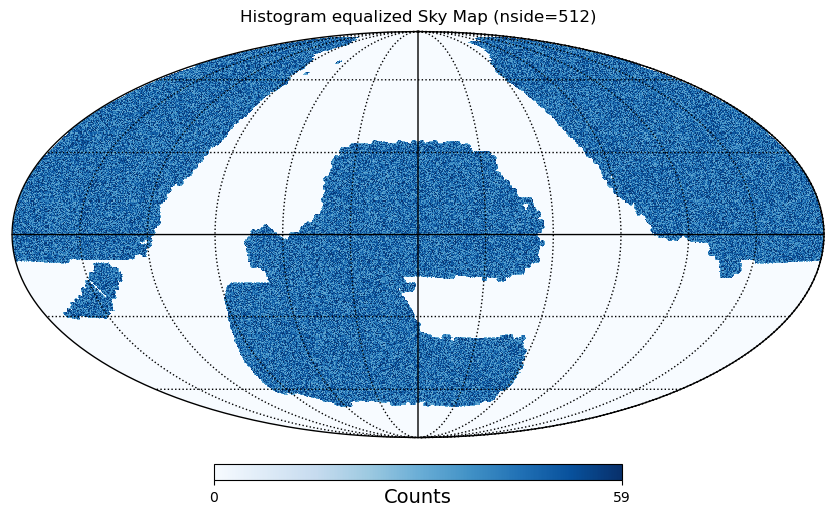

In [42]:
import healpy as hp
import numpy as np
import healpy.visufunc as hv
#ra_array=final_unique_rows['RA']
#dec_array=final_unique_rows['DEC']
nside =512
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - np.rad2deg(rand_dec).data)  # theta = 0 at North Pole
phi = -np.radians(np.rad2deg(rand_ra).data) 
pix_indices = hp.ang2pix(nside, theta, phi)
hpx_map = np.zeros(npix, dtype=int)

ix,counts=np.unique(pix_indices,return_counts=True)
   # fill the fullsky map
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map,cmap='Blues', unit='Counts',norm='hist',title=f"Histogram equalized Sky Map (nside={nside})")
hp.graticule()

In [33]:
len(rand_ra)

51738616

In [13]:
random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms.fits')[1].read()

In [16]:
rand_table=Table(random_compiled)

In [18]:
rand_table = rand_table[rand_table['DEC'] > -30]

In [17]:
table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())


In [19]:
import numpy as np

import Corrfunc

from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks

from Corrfunc.io import read_catalog

from Corrfunc.utils import convert_3d_counts_to_cf

In [21]:
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  

In [33]:

rand_N = len(RA_random)
# Setup the bins
nbins = 10
bins = np.linspace(0.1, 10.0, nbins + 1) # note the +1 to nbins
# Number of threads to use
nthreads = 120
# Auto pair counts in DD
autocorr=1
DD_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data)
# Cross pair counts in DR
print('done with dd counts')
autocorr=0
DR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data,RA2=RA_random, DEC2=DEC_random)

# Auto pairs counts in RR
print("done with dr counts")
autocorr=1

RR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_random,DEC_random)

# All the pair counts are done, get the angular correlation function
print('done with rr counts')
wtheta = convert_3d_counts_to_cf(N, N, rand_N, rand_N,DD_counts, DR_counts,DR_counts, RR_counts)


RuntimeError: RuntimeError occurred

In [ ]:
autocorr=0
DR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data,RA2=RA_random, DEC2=DEC_random)


In [ ]:
with open('wtheta.pkl', 'wb') as f:
    pickle.dump(wtheta, f)

(array([362., 403., 301., 311., 348., 360., 440., 446., 499., 532., 576.,
        577., 573., 545., 500., 518., 454., 389., 325., 334., 267., 200.,
        164., 151., 102.,  94.,  62.,  51.,  51.,  23.,  14.,   9.,   8.,
          4.,   3.,   0.,   2.,   0.,   0.,   2.]),
 array([2.20572211e-05, 4.27572362e-02, 8.54924153e-02, 1.28227594e-01,
        1.70962773e-01, 2.13697952e-01, 2.56433131e-01, 2.99168310e-01,
        3.41903489e-01, 3.84638668e-01, 4.27373847e-01, 4.70109026e-01,
        5.12844205e-01, 5.55579384e-01, 5.98314563e-01, 6.41049743e-01,
        6.83784922e-01, 7.26520101e-01, 7.69255280e-01, 8.11990459e-01,
        8.54725638e-01, 8.97460817e-01, 9.40195996e-01, 9.82931175e-01,
        1.02566635e+00, 1.06840153e+00, 1.11113671e+00, 1.15387189e+00,
        1.19660707e+00, 1.23934225e+00, 1.28207743e+00, 1.32481261e+00,
        1.36754779e+00, 1.41028296e+00, 1.45301814e+00, 1.49575332e+00,
        1.53848850e+00, 1.58122368e+00, 1.62395886e+00, 1.66669404e+00,
      

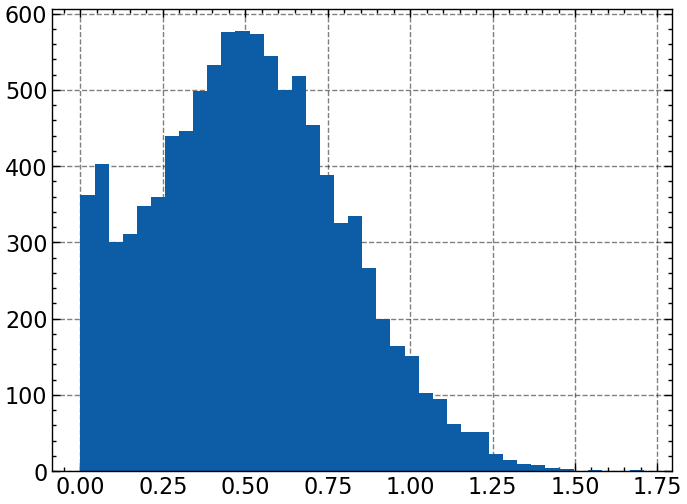

In [10]:
plt.hist(z,bins=40)

In [41]:
ra= np.random.normal(1,0.5,500000)
dec= np.random.uniform(-1,0.5,500000)
z = 0.5 + 0.3*np.sin(np.radians(dec)) + 0.2*np.cos(np.radians(ra-180)) #+np.random.normal(0,0.005,len(ra))
z = np.clip(z, 0, None) 

In [42]:
theta

array([0.63054806, 2.14352579, 1.45542613, ..., 1.56882144, 2.27067559,
       1.36668965])

In [43]:
nside=64
import healpy as hp
npix=hp.nside2npix(nside)
theta = np.pi/2 - dec
phi = ra
hpix = hp.ang2pix(nside, theta, phi)
hpx_map = np.full(npix, hp.UNSEEN, dtype=float)  # default UNSEEN for empty pixels

sum_z = np.bincount(hpix, weights=z, minlength=npix)
# Number of points per pixel
counts = np.bincount(hpix, minlength=npix)
# Mean Z per pixel
hpx_map = sum_z / counts

/tmp/ipykernel_36059/2895127996.py:13: RuntimeWarning: invalid value encountered in divide
  hpx_map = sum_z / counts


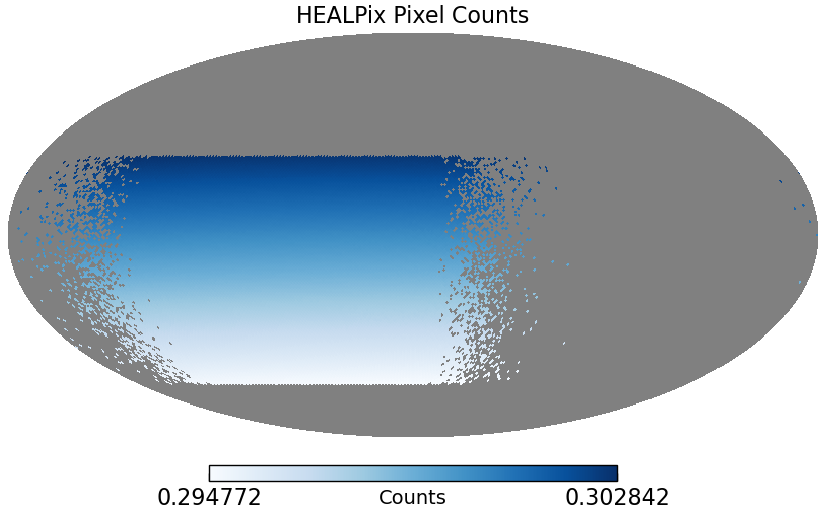

In [44]:
hp.mollview(hpx_map, title="HEALPix Pixel Counts", unit="Counts", cmap="Blues")
    #hp.mollview(hpx_map, title="Redshift distribution", unit="Counts", cmap="Blues", norm='hist')
#plt.gcf().savefig("healpix_z_hist.png", dpi=300, bbox_inches="tight")


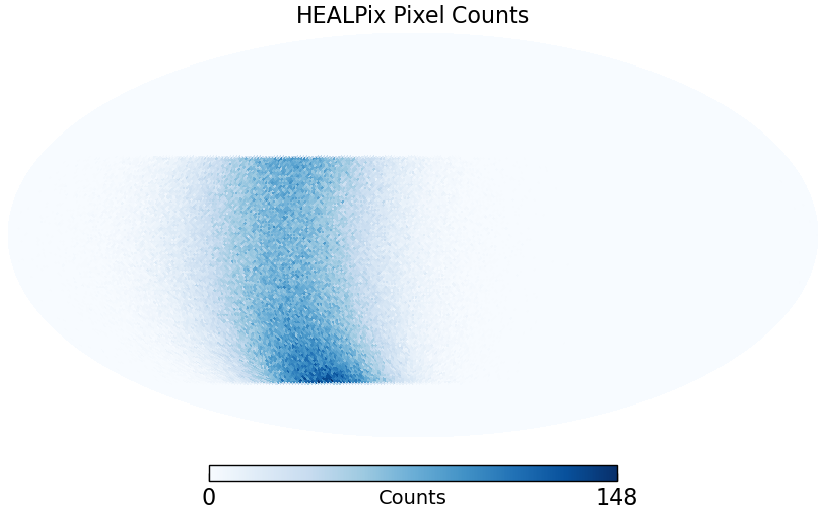

In [45]:
sum_z2 = np.bincount(hpix, minlength=npix)
hp.mollview(sum_z2, title="HEALPix Pixel Counts", unit="Counts", cmap="Blues")
